In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

# 1. 데이터 로드 및 분리
df = pd.read_csv('./data/kia_ml_test_ready.csv')
y = df['현재가격']
X = df.drop(columns=['매물ID', '현재가격'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 LightGBM 분위수 회귀 모델 학습 시작...")
start_time = time.time()

# 2. LightGBM 모델 세팅 및 학습
# objective='quantile' 로 설정하고 alpha값(분위수)을 지정합니다.
model_lgb_lower = LGBMRegressor(objective='quantile', alpha=0.25, n_estimators=300, learning_rate=0.1, random_state=42)
model_lgb_median = LGBMRegressor(objective='quantile', alpha=0.50, n_estimators=300, learning_rate=0.1, random_state=42)
model_lgb_upper = LGBMRegressor(objective='quantile', alpha=0.75, n_estimators=300, learning_rate=0.1, random_state=42)

model_lgb_lower.fit(X_train, y_train)
model_lgb_median.fit(X_train, y_train)
model_lgb_upper.fit(X_train, y_train)

print(f"✅ 학습 완료! (소요 시간: {time.time() - start_time:.2f}초)\n")

# 3. 예측 및 평가 (50% 적정가 기준)
pred_lower = model_lgb_lower.predict(X_test)
pred_median = model_lgb_median.predict(X_test)
pred_upper = model_lgb_upper.predict(X_test)

mae = mean_absolute_error(y_test, pred_median)
r2 = r2_score(y_test, pred_median)

print(f"📊 [LightGBM 성능 평가]")
print(f"- 평균 절대 오차(MAE): {mae:.1f} 만원")
print(f"- 설명력 (R-squared, R²): {r2:.4f}\n")

# 4. 결과 출력
results = pd.DataFrame({
    '실제가격(만원)': y_test.values[:5],
    '추천 하한가(25%)': pred_lower[:5].round(0).astype(int),
    '적정 예측가(50%)': pred_median[:5].round(0).astype(int),
    '추천 상한가(75%)': pred_upper[:5].round(0).astype(int)
})
print("=== 🚗 LightGBM 예측 결과 ===")
print(results.to_string(index=False))

🚀 LightGBM 분위수 회귀 모델 학습 시작...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 3061, number of used features: 53
[LightGBM] [Info] Start training from score 1129.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 3061, number of used features: 53
[LightGBM] [Info] Start training from score 1999.000

In [4]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# 1. 데이터 로드 및 분리
df = pd.read_csv('./data/kia_ml_test_ready.csv')
y = df['현재가격']
X = df.drop(columns=['매물ID', '현재가격'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 XGBoost 분위수 회귀 모델 학습 시작...")
start_time = time.time()

# 2. XGBoost 모델 세팅 및 학습
# objective='reg:quantileerror' 로 설정하고 quantile_alpha 값을 지정합니다.
# 결측치는 자동으로 처리됩니다.
model_xgb_lower = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.25, n_estimators=300, learning_rate=0.1, random_state=42)
model_xgb_median = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.50, n_estimators=300, learning_rate=0.1, random_state=42)
model_xgb_upper = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.75, n_estimators=300, learning_rate=0.1, random_state=42)

model_xgb_lower.fit(X_train, y_train)
model_xgb_median.fit(X_train, y_train)
model_xgb_upper.fit(X_train, y_train)

print(f"✅ 학습 완료! (소요 시간: {time.time() - start_time:.2f}초)\n")

# 3. 예측 및 평가 (50% 적정가 기준)
pred_lower = model_xgb_lower.predict(X_test)
pred_median = model_xgb_median.predict(X_test)
pred_upper = model_xgb_upper.predict(X_test)

mae = mean_absolute_error(y_test, pred_median)
r2 = r2_score(y_test, pred_median)

print(f"📊 [XGBoost 성능 평가]")
print(f"- 평균 절대 오차(MAE): {mae:.1f} 만원")
print(f"- 설명력 (R-squared, R²): {r2:.4f}\n")

# 4. 결과 출력
results = pd.DataFrame({
    '실제가격(만원)': y_test.values[:5],
    '추천 하한가(25%)': pred_lower[:5].round(0).astype(int),
    '적정 예측가(50%)': pred_median[:5].round(0).astype(int),
    '추천 상한가(75%)': pred_upper[:5].round(0).astype(int)
})
print("=== 🚗 XGBoost 예측 결과 ===")
print(results.to_string(index=False))

🚀 XGBoost 분위수 회귀 모델 학습 시작...
✅ 학습 완료! (소요 시간: 1.37초)

📊 [XGBoost 성능 평가]
- 평균 절대 오차(MAE): 261.8 만원
- 설명력 (R-squared, R²): 0.6907

=== 🚗 XGBoost 예측 결과 ===
 실제가격(만원)  추천 하한가(25%)  적정 예측가(50%)  추천 상한가(75%)
     3770         3383         3543         3134
     1419         1506         1631         1720
      478          525          499          569
     2630         2902         2834         2905
     3790         3148         3223         3352


In [6]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

# 1. 데이터 로드
df = pd.read_csv('.\data\kia_ml_test_ready.csv')

# -------------------------------------------------------------------
# 🚀 성능 향상 포인트 A: 철저한 이상치(Outlier) 제거
# 너무 싸거나 비싼 차, 주행거리가 비정상적인 차는 학습에서 배제합니다.
# -------------------------------------------------------------------
df = df[(df['현재가격'] >= 200) & (df['현재가격'] <= 8000)] # 200만원 ~ 8000만원
df = df[(df['주행거리_km'] >= 1000) & (df['주행거리_km'] <= 300000)] # 1천km ~ 30만km

y = df['현재가격']
X = df.drop(columns=['매물ID', '현재가격'], errors='ignore')

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------------------------------------------
# 🚀 성능 향상 포인트 B: 타겟 변수 로그 변환 (Log1p)
# 가격 데이터의 꼬리를 줄여 AI가 더 쉽게 패턴을 찾도록 도와줍니다.
# -------------------------------------------------------------------
y_train_log = np.log1p(y_train)

print("🚀 LightGBM (로그 변환 + 이상치 제거) 모델 학습 시작...")
start_time = time.time()

# -------------------------------------------------------------------
# 🚀 성능 향상 포인트 C: 파라미터 미세 조정 (num_leaves, colsample 등 추가)
# -------------------------------------------------------------------
# 적정가(50%) 모델만 먼저 빠르게 테스트하여 R² 향상 여부를 봅니다.
model_lgb_median = LGBMRegressor(
    objective='quantile', 
    alpha=0.50, 
    n_estimators=500,        # 트리 개수 증가
    learning_rate=0.05,      # 보폭을 줄여 정밀하게 (대신 n_estimators는 늘림)
    num_leaves=31,           # 리프 노드 수 조절
    colsample_bytree=0.8,    # 컬럼을 80%만 샘플링하여 과적합 방지
    subsample=0.8,           # 데이터 샘플링 비율
    random_state=42,
    verbose=-1
)

# 로그 변환된 가격(y_train_log)으로 학습
model_lgb_median.fit(X_train, y_train_log)

# -------------------------------------------------------------------
# 🚀 성능 향상 포인트 D: 예측 후 원래 가격으로 복원 (Expm1)
# -------------------------------------------------------------------
# 예측값도 로그 형태이므로, expm1을 통해 원래 단위(만원)로 되돌려줍니다.
pred_median_log = model_lgb_median.predict(X_test)
pred_median = np.expm1(pred_median_log)

# 평가 지표 계산
mae = mean_absolute_error(y_test, pred_median)
r2 = r2_score(y_test, pred_median)

print(f"✅ 학습 완료! (소요 시간: {time.time() - start_time:.2f}초)\n")
print(f"📊 [성능 향상 테스트 결과]")
print(f"- 평균 절대 오차(MAE): {mae:.1f} 만원")
print(f"- 설명력 (R-squared, R²): {r2:.4f}\n")

🚀 LightGBM (로그 변환 + 이상치 제거) 모델 학습 시작...
✅ 학습 완료! (소요 시간: 0.22초)

📊 [성능 향상 테스트 결과]
- 평균 절대 오차(MAE): 154.1 만원
- 설명력 (R-squared, R²): 0.9358



In [9]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 데이터 로드 및 이상치 가볍게 제거
df = pd.read_csv('./data/kia_ml_test_ready.csv')
df = df[(df['현재가격'] >= 200) & (df['현재가격'] <= 8000)]

y = df['현재가격']
X = df.drop(columns=['매물ID', '현재가격'], errors='ignore')

# 2. 5-Fold 교차 검증 준비 (데이터를 5조각으로 내어 돌아가며 테스트)
kf = KFold(n_splits=6, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print("🚀 5-Fold 교차 검증(Cross Validation) 시작...")

# 5번 반복 학습 및 평가
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # 모델 학습 (적정가 기준)
    model = LGBMRegressor(objective='quantile', alpha=0.50, n_estimators=500, learning_rate=0.2, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    
    # 예측 및 평가
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    mae_scores.append(mae)
    r2_scores.append(r2)
    print(f"Fold {fold+1} - MAE: {mae:.1f}만원, R²: {r2:.4f}")

# 3. 최종 '진짜' 성능 확인
print("\n📊 [K-Fold 최종 검증 결과]")
print(f"👉 평균 MAE: {np.mean(mae_scores):.1f} 만원")
print(f"👉 평균 R²: {np.mean(r2_scores):.4f}")

if np.mean(r2_scores) < 0.8:
    print("💡 분석: 하나의 데이터셋에서는 0.93이 나왔지만 K-Fold 평균이 낮다면 과적합이 맞습니다. 1만 건 추가가 시급합니다!")
else:
    print("💡 분석: K-Fold 평균도 매우 높습니다. 모델이 상당히 안정적입니다!")

🚀 5-Fold 교차 검증(Cross Validation) 시작...
Fold 1 - MAE: 152.6만원, R²: 0.9591
Fold 2 - MAE: 161.1만원, R²: 0.9586
Fold 3 - MAE: 185.2만원, R²: 0.9277
Fold 4 - MAE: 174.3만원, R²: 0.9424
Fold 5 - MAE: 195.1만원, R²: 0.8940
Fold 6 - MAE: 216.4만원, R²: 0.8477

📊 [K-Fold 최종 검증 결과]
👉 평균 MAE: 180.8 만원
👉 평균 R²: 0.9216
💡 분석: K-Fold 평균도 매우 높습니다. 모델이 상당히 안정적입니다!


In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# 1. 데이터 로드
df = pd.read_csv('./data/kia_ml_test_ready.csv')

# -------------------------------------------------------------------
# 🚀 수정된 부분: 옵션 관련 컬럼 자동으로 찾아서 제외하기
# 데이터프레임 컬럼 중 이름에 '옵션'이 포함된 모든 컬럼 리스트 추출
# -------------------------------------------------------------------
option_cols = [col for col in df.columns if '옵션' in col]
print(f"✂️ 제외된 옵션 컬럼들 ({len(option_cols)}개): {option_cols}\n")

# Y(타겟) 설정
y = df['현재가격']

# X(특성) 설정: '매물ID', '현재가격', 그리고 '옵션 컬럼' 전체 삭제
drop_cols = ['매물ID', '현재가격'] + option_cols
X = df.drop(columns=drop_cols, errors='ignore')

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 XGBoost 분위수 회귀 모델 학습 시작 (옵션 특성 제외)...")
start_time = time.time()

# 2. XGBoost 모델 세팅 및 학습 (결측치는 자동 처리됨)
model_xgb_lower = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.25, n_estimators=300, learning_rate=0.1, random_state=42)
model_xgb_median = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.50, n_estimators=300, learning_rate=0.1, random_state=42)
model_xgb_upper = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.75, n_estimators=300, learning_rate=0.1, random_state=42)

model_xgb_lower.fit(X_train, y_train)
model_xgb_median.fit(X_train, y_train)
model_xgb_upper.fit(X_train, y_train)

print(f"✅ 학습 완료! (소요 시간: {time.time() - start_time:.2f}초)\n")

# 3. 예측 및 평가 (50% 적정가 기준)
pred_lower = model_xgb_lower.predict(X_test)
pred_median = model_xgb_median.predict(X_test)
pred_upper = model_xgb_upper.predict(X_test)

mae = mean_absolute_error(y_test, pred_median)
r2 = r2_score(y_test, pred_median)

print(f"📊 [옵션 제외 모델 성능 평가]")
print(f"- 평균 절대 오차(MAE): {mae:.1f} 만원")
print(f"- 설명력 (R-squared, R²): {r2:.4f}\n")

# 4. 결과 출력
results = pd.DataFrame({
    '실제가격(만원)': y_test.values[:5],
    '추천 하한가(25%)': pred_lower[:5].round(0).astype(int),
    '적정 예측가(50%)': pred_median[:5].round(0).astype(int),
    '추천 상한가(75%)': pred_upper[:5].round(0).astype(int)
})
print("=== 🚗 XGBoost 예측 결과 (옵션 없이 연식/사고/주행거리 등으로만 예측) ===")
print(results.to_string(index=False))

✂️ 제외된 옵션 컬럼들 (14개): ['옵션_기본코드 개수', '옵션_선택코드 개수', '옵션_튜닝코드 개수', '옵션_기타개수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트']

🚀 XGBoost 분위수 회귀 모델 학습 시작 (옵션 특성 제외)...
✅ 학습 완료! (소요 시간: 1.14초)

📊 [옵션 제외 모델 성능 평가]
- 평균 절대 오차(MAE): 315.5 만원
- 설명력 (R-squared, R²): 0.6584

=== 🚗 XGBoost 예측 결과 (옵션 없이 연식/사고/주행거리 등으로만 예측) ===
 실제가격(만원)  추천 하한가(25%)  적정 예측가(50%)  추천 상한가(75%)
     3770         3615         3902         4380
     1419         1494         1645         1703
      478          429          478          531
     2630         2538         2741         2769
     3790         3262         3503         3701


데이터를 로딩하고 전처리합니다...
이상치 필터링 완료: 현재 데이터 갯수 11002개
트리 기반 분위수 회귀 모델(GradientBoosting) 학습을 시작합니다. 잠시만 기다려주세요...

[10th 백분위수] 모델 학습 완료!
[25th 백분위수] 모델 학습 완료!
[50th 백분위수] 모델 학습 완료!
[75th 백분위수] 모델 학습 완료!
[90th 백분위수] 모델 학습 완료!

🎯 모델 예측 성능 (q=0.5 중앙값 기준 R^2): 0.8090 (80.9%)

📊 [Top 10 핵심 영향 변수] (p-value 대체재)
            Feature  Importance (%)
log_model_avg_price          65.88%
        log_mileage           9.49%
               차량연령           6.31%
   log_displacement           4.00%
             사고강도점수           2.73%
    주요옵션_헤드램프 (LED)           1.77%
          주요옵션_통풍시트           1.19%
                좌석수           1.09%
           주요옵션_선루프           1.03%
      제조사_르노코리아(삼성)           0.79%


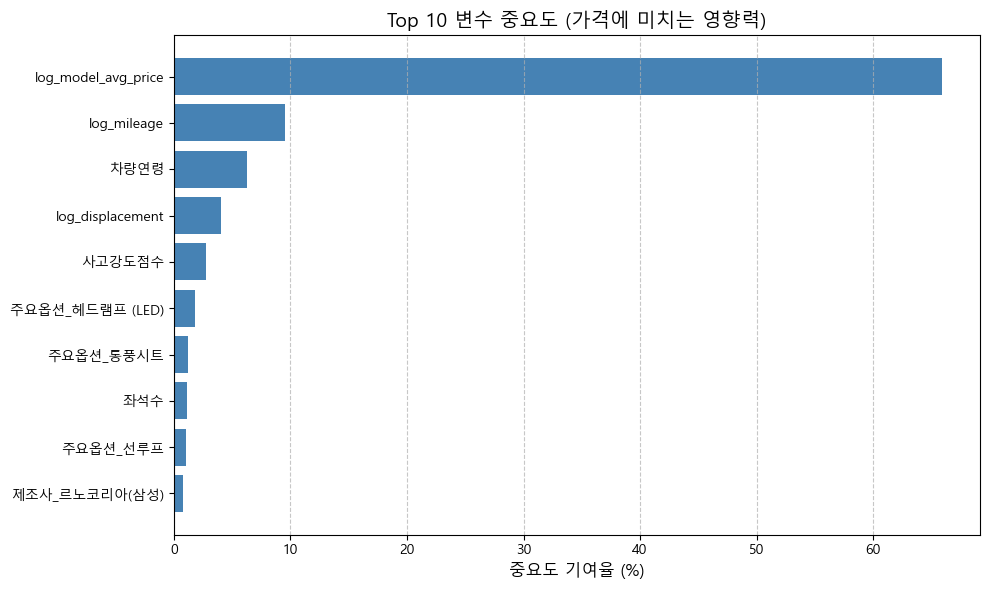

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 1. 데이터 로드 및 결측치 제거
print("데이터를 로딩하고 전처리합니다...")
df = pd.read_csv('./data/encar_feature_processed_with_model_avg_te.csv').dropna()

# 2. 필수 변수 로그(Log) 변환 (가격, 주행거리, 배기량, 모델평균가)
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])
df['log_model_avg_price'] = np.log1p(df['모델_평균가_TE'])

# 3. 모델링 변수 분리
cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', '모델_평균가_TE', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

# 학습용 / 테스트용 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 이상치(Outlier) 제거 함수 - IQR 방식
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 1.5 * IQR 기준 적용 (가장 보편적인 이상치 탐지 방식)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

# 가격, 주행거리, 차량연령 등 핵심 변수에 대해 연속으로 이상치 필터링
df = remove_outliers_iqr(df, '현재가격_만원')
df = remove_outliers_iqr(df, '주행거리_km')
df = remove_outliers_iqr(df, '차량연령')

print(f"이상치 필터링 완료: 현재 데이터 갯수 {len(df)}개")

# --- 이 아래부터는 기존의 '3. 필수 변수 로그 변환' 코드와 동일하게 진행 ---
# 4. 분위수 회귀 (Quantile Regression) 모델 학습
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
models = {}
predictions = {}

print("트리 기반 분위수 회귀 모델(GradientBoosting) 학습을 시작합니다. 잠시만 기다려주세요...\n")

for q in quantiles:
    # 핵심: loss='quantile' 지정과 alpha 값으로 분위수 설정
    model = GradientBoostingRegressor(
        loss='quantile', 
        alpha=q, 
        n_estimators=150,    # 나무의 개수 (성능을 위해 150개 사용)
        learning_rate=0.1, 
        max_depth=5,         # 비선형성 및 교호작용 자동 탐지 깊이
        random_state=42
    )
    model.fit(X_train, y_train)
    
    models[q] = model
    predictions[q] = model.predict(X_test)
    print(f"[{q*100:02.0f}th 백분위수] 모델 학습 완료!")

# 5. 성능 평가 (R^2 Score - 중앙값 기준)
# 중앙값(q=0.5)은 기존 통계 모델의 R^2와 직접 비교가 가능합니다.
r2_median = r2_score(y_test, predictions[0.5])
print(f"\n=========================================")
print(f"🎯 모델 예측 성능 (q=0.5 중앙값 기준 R^2): {r2_median:.4f} ({(r2_median*100):.1f}%)")
print(f"=========================================\n")

# 6. P-value를 대체하는 '변수 중요도 (Feature Importance)' 추출
# 어떤 변수가 가격을 결정하는 데 가장 유의미했는지 (p-value의 역할) 추출
importances = models[0.5].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance (%)': importances * 100
})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

print("📊 [Top 10 핵심 영향 변수] (p-value 대체재)")
print(feat_imp_df.head(10).to_string(index=False, float_format="%.2f%%"))

# 7. 시각화: 변수 중요도 차트
plt.figure(figsize=(10, 6))
top_features = feat_imp_df.head(10)
plt.barh(top_features['Feature'][::-1], top_features['Importance (%)'][::-1], color='steelblue')
plt.title('Top 10 변수 중요도 (가격에 미치는 영향력)', fontsize=14)
plt.xlabel('중요도 기여율 (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 예측 결과 (중앙값 q=0.5 기준)
pred_log = predictions[0.5]

# 1. 로그 스케일에서의 평가
r2_log = r2_score(y_test, pred_log)
mae_log = mean_absolute_error(y_test, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))

# 2. 원래 스케일(만원 단위)로 복원 (expm1 사용)
y_test_orig = np.expm1(y_test)
pred_orig = np.expm1(pred_log)

mae_orig = mean_absolute_error(y_test_orig, pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, pred_orig))

print(f"\n=========================================")
print(f"🎯 모델 예측 성능 (q=0.5 중앙값 기준)")
print(f"=========================================")
print(f"[로그 스케일]")
print(f" - R^2 Score : {r2_log:.4f} ({(r2_log*100):.1f}%)")
print(f" - MAE       : {mae_log:.4f}")
print(f" - RMSE      : {rmse_log:.4f}")
print(f"\n[실제 가격 스케일 (만원)]")
print(f" - MAE       : {mae_orig:,.0f} 만원")
print(f" - RMSE      : {rmse_orig:,.0f} 만원")
print(f"=========================================\n")


🎯 모델 예측 성능 (q=0.5 중앙값 기준)
[로그 스케일]
 - R^2 Score : 0.8090 (80.9%)
 - MAE       : 0.1400
 - RMSE      : 0.3799

[실제 가격 스케일 (만원)]
 - MAE       : 298 만원
 - RMSE      : 968 만원



데이터를 로딩하고 전처리합니다...
✅ 이상치 제거 완료: 총 11617개 중 615개 제거 (남은 데이터: 11002개)

트리 기반 분위수 회귀 모델(GradientBoosting) 학습을 시작합니다...
✅ 모델 학습 완료!

🎯 최종 예측 성능 (q=0.5 중앙값 기준)
[1. 로그 스케일 (Log Scale)]
 - R^2 Score : 0.8979 (89.8%)
 - MAE       : 0.1113
 - RMSE      : 0.2574

[2. 원래 스케일 (만원 단위)]
 - MAE       : 178 만원
 - RMSE      : 329 만원



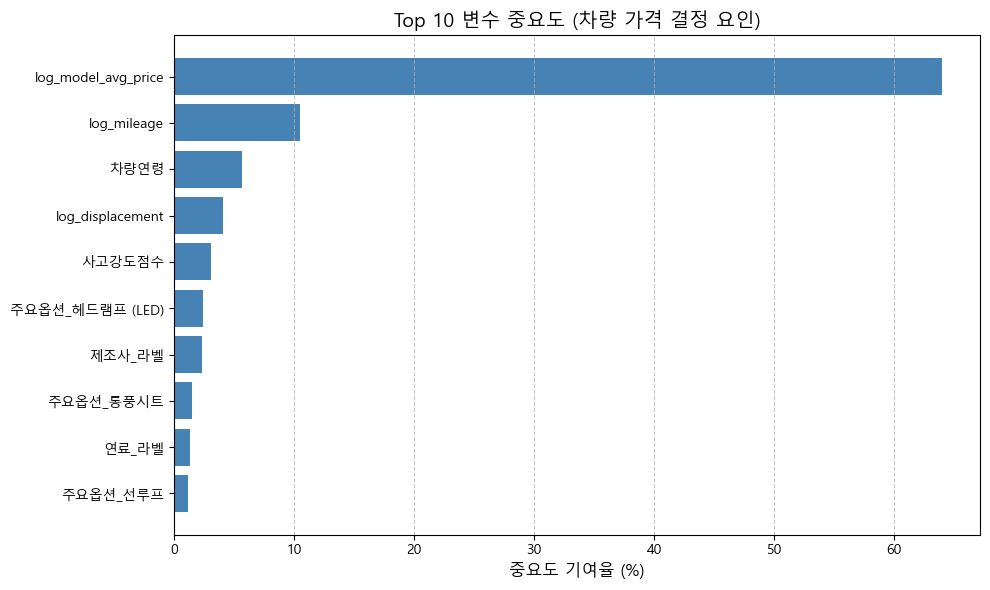

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드
# ==========================================
print("데이터를 로딩하고 전처리합니다...")
df = pd.read_csv('./data/encar_feature_label_encoded.csv').dropna()
initial_len = len(df)

# ==========================================
# 2. 이상치(Outlier) 제거 (IQR 방식)
# ==========================================
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 1.5 * IQR 기준 적용
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

# 핵심 변수(가격, 주행거리, 차량연령)에 대해 이상치 제거
for col in ['현재가격_만원', '주행거리_km', '차량연령']:
    df = remove_outliers_iqr(df, col)

removed_count = initial_len - len(df)
print(f"✅ 이상치 제거 완료: 총 {initial_len}개 중 {removed_count}개 제거 (남은 데이터: {len(df)}개)")

# ==========================================
# 3. 데이터 전처리 (로그 변환 및 변수 분리)
# ==========================================
# 편차가 큰 수치형 변수 로그(Log) 변환
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])
df['log_model_avg_price'] = np.log1p(df['모델_평균가_TE'])

# 분석에 사용할 피처 선택 (문자열 및 변환 전 원본 컬럼 제외)
cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', '모델_평균가_TE', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

# 학습용(80%)과 테스트용(20%) 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. 트리 기반 분위수 회귀 모델 학습 (q=0.5 중앙값)
# ==========================================
print("\n트리 기반 분위수 회귀 모델(GradientBoosting) 학습을 시작합니다...")
model = GradientBoostingRegressor(
    loss='quantile', 
    alpha=0.5,           # 분위수(Quantile) 설정: 0.5는 중앙값
    n_estimators=150,    # 나무의 개수
    learning_rate=0.1, 
    max_depth=5,         # 비선형성 및 교호작용 자동 탐지 깊이
    random_state=42
)
model.fit(X_train, y_train)
print("✅ 모델 학습 완료!")

# ==========================================
# 5. 모델 예측 및 성능 평가 (MAE, RMSE, R^2)
# ==========================================
# 예측 수행 (로그 스케일)
pred_log = model.predict(X_test)

# (1) 로그 스케일에서의 평가 지표
r2_log = r2_score(y_test, pred_log)
mae_log = mean_absolute_error(y_test, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))

# (2) 원래 스케일(만원 단위)로 복원 (expm1 사용)
y_test_orig = np.expm1(y_test)
pred_orig = np.expm1(pred_log)

mae_orig = mean_absolute_error(y_test_orig, pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, pred_orig))

print(f"\n=========================================")
print(f"🎯 최종 예측 성능 (q=0.5 중앙값 기준)")
print(f"=========================================")
print(f"[1. 로그 스케일 (Log Scale)]")
print(f" - R^2 Score : {r2_log:.4f} ({(r2_log*100):.1f}%)")
print(f" - MAE       : {mae_log:.4f}")
print(f" - RMSE      : {rmse_log:.4f}")
print(f"\n[2. 원래 스케일 (만원 단위)]")
print(f" - MAE       : {mae_orig:,.0f} 만원")
print(f" - RMSE      : {rmse_orig:,.0f} 만원")
print(f"=========================================\n")

# ==========================================
# 6. (선택) 변수 중요도 시각화
# ==========================================
importances = model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance (%)': importances * 100
})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
top_features = feat_imp_df.head(10)
plt.barh(top_features['Feature'][::-1], top_features['Importance (%)'][::-1], color='steelblue')
plt.title('Top 10 변수 중요도 (차량 가격 결정 요인)', fontsize=14)
plt.xlabel('중요도 기여율 (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

🚀 3대 트리 모델 학습 및 평가를 시작합니다...

[Random Forest] 학습 중...
[XGBoost] 학습 중...
[LightGBM] 학습 중...

🏆 모델별 예측 성능 비교 결과 (단위: 만원)
              R2 Score (%) MAE (만원) RMSE (만원)
Model                                        
Random Forest         87.6    212.6     418.4
XGBoost               90.2    170.8     312.4
LightGBM              89.8    179.0     334.6



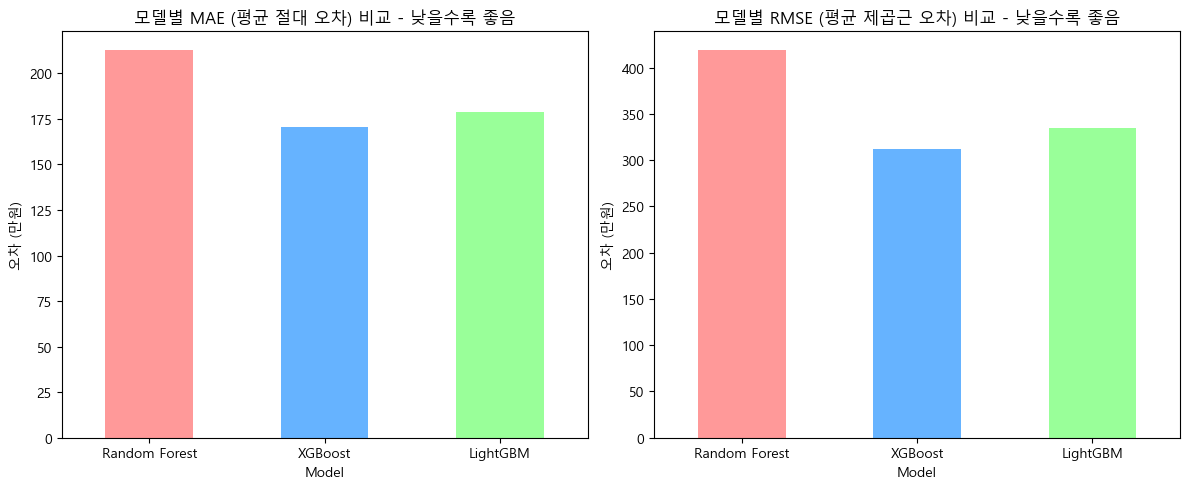

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 모델 임포트
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치(Outlier) 제거
# ==========================================
df = pd.read_csv('./data/encar_feature_label_encoded.csv').dropna()


def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

for col in ['현재가격_만원', '주행거리_km', '차량연령']:
    df = remove_outliers_iqr(df, col)

# ==========================================
# 2. 데이터 전처리 (로그 변환 및 변수 분리)
# ==========================================
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])
df['log_model_avg_price'] = np.log1p(df['모델_평균가_TE'])

cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', '모델_평균가_TE', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. 3대 트리 모델 설정 (중앙값 예측 세팅)
# ==========================================
# 딕셔너리 형태로 3가지 모델 정의
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=150, 
        max_depth=15, 
        random_state=42,
        n_jobs=-1 # 모든 CPU 코어 사용 (속도 향상)
    ),
    "XGBoost": XGBRegressor(
        objective='reg:absoluteerror', # MAE(중앙값) 최적화
        n_estimators=150, 
        learning_rate=0.1, 
        max_depth=6, 
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        objective='quantile', 
        alpha=0.5,                    # 분위수 0.5 (중앙값)
        n_estimators=150, 
        learning_rate=0.1, 
        max_depth=6, 
        random_state=42,
        verbose=-1
    )
}

# ==========================================
# 4. 모델 학습 및 MAE/RMSE 비교
# ==========================================
print("🚀 3대 트리 모델 학습 및 평가를 시작합니다...\n")

results = []

for model_name, model in models.items():
    print(f"[{model_name}] 학습 중...")
    model.fit(X_train, y_train)
    
    # 예측 (로그 스케일)
    pred_log = model.predict(X_test)
    
    # 실제 만원 단위 스케일로 복원
    y_test_orig = np.expm1(y_test)
    pred_orig = np.expm1(pred_log)
    
    # 평가 지표 계산
    r2 = r2_score(y_test, pred_log)
    mae = mean_absolute_error(y_test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))
    
    results.append({
        'Model': model_name,
        'R2 Score (%)': r2 * 100,
        'MAE (만원)': mae,
        'RMSE (만원)': rmse
    })

# ==========================================
# 5. 결과 출력 및 시각화
# ==========================================
results_df = pd.DataFrame(results).set_index('Model')

print("\n=======================================================")
print("🏆 모델별 예측 성능 비교 결과 (단위: 만원)")
print("=======================================================")
# 소수점 포맷팅해서 출력
print(results_df.applymap(lambda x: f"{x:,.1f}").to_string())
print("=======================================================\n")

# 막대 그래프로 오차(MAE, RMSE) 시각적 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE 그래프
results_df['MAE (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[0])
axes[0].set_title('모델별 MAE (평균 절대 오차) 비교 - 낮을수록 좋음')
axes[0].set_ylabel('오차 (만원)')
axes[0].tick_params(axis='x', rotation=0)

# RMSE 그래프
results_df['RMSE (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[1])
axes[1].set_title('모델별 RMSE (평균 제곱근 오차) 비교 - 낮을수록 좋음')
axes[1].set_ylabel('오차 (만원)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

🚀 3대 트리 모델 학습 및 평가를 시작합니다...

📊 하위 10%, 상위 90% 분위수 모델을 추가 학습하여 구간 폭(Width)을 계산합니다...

🏆 모델별 예측 성능 및 Range 비교 결과 (단위: 만원)
              R2 Score (%) MAE (만원) RMSE (만원) 최소 예측가   최대 예측가 Range (최대-최소)
Model                                                                      
Random Forest         87.6    212.6     418.4   65.0  5,170.2       5,105.3
XGBoost               90.2    170.8     312.4  180.4  5,554.7       5,374.3
LightGBM              89.8    179.0     334.6  173.2  5,405.6       5,232.5

🎯 [핵심] 분위수 회귀 (80% 신뢰구간) Width 및 Coverage 평가
✔️ 평균 신뢰구간 폭(Mean Interval Width) : 544.9 만원
   (모델이 '이 차는 최소 A만원 ~ 최대 B만원입니다'라고 제시한 가격 간격의 평균)
✔️ 실제값 포함 확률(Coverage Range)      : 74.1 %
   (실제 거래된 가격이 AI가 예측한 [하위10% ~ 상위90%] 구간 안에 들어간 비율)



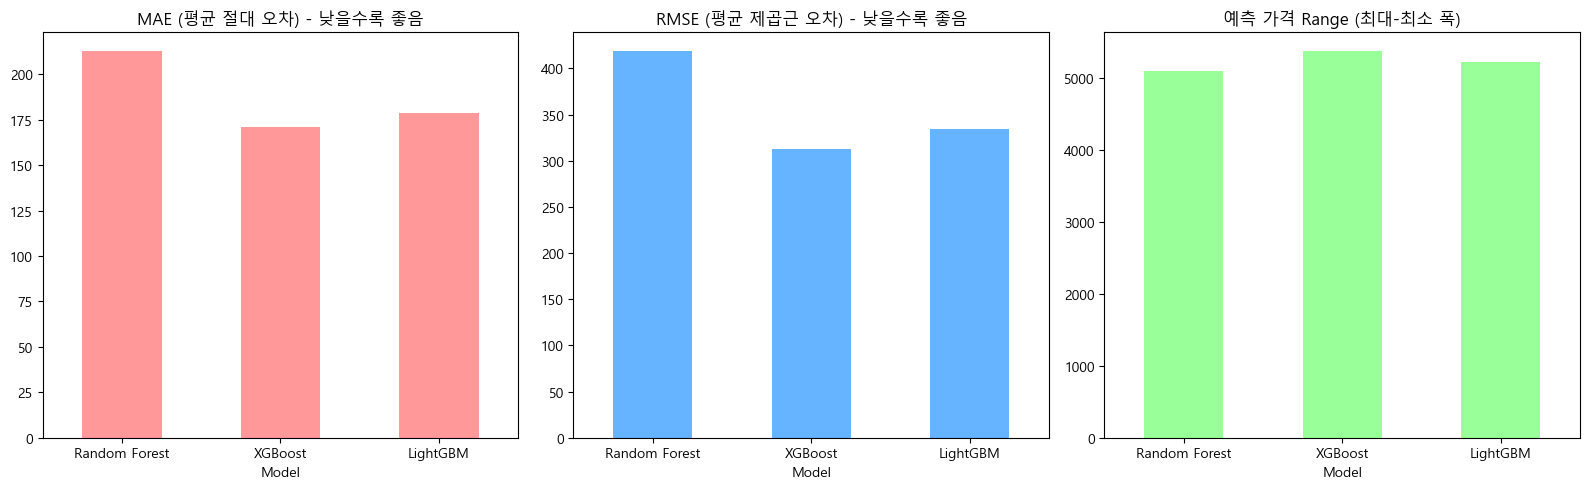

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 모델 임포트
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치(Outlier) 제거
# ==========================================
df =pd.read_csv('./data/encar_feature_label_encoded.csv').dropna()

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

for col in ['현재가격_만원', '주행거리_km', '차량연령']:
    df = remove_outliers_iqr(df, col)

# ==========================================
# 2. 데이터 전처리 (로그 변환 및 변수 분리)
# ==========================================
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])
df['log_model_avg_price'] = np.log1p(df['모델_평균가_TE'])

cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', '모델_평균가_TE', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. 3대 트리 모델 설정 (중앙값 예측 세팅)
# ==========================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(objective='reg:absoluteerror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42),
    "LightGBM": LGBMRegressor(objective='quantile', alpha=0.5, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
}

# ==========================================
# 4. 모델 학습 및 MAE, RMSE, Range 산출
# ==========================================
print("🚀 3대 트리 모델 학습 및 평가를 시작합니다...\n")
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    # 예측 및 스케일 복원
    pred_log = model.predict(X_test)
    y_test_orig = np.expm1(y_test)
    pred_orig = np.expm1(pred_log)
    
    # 기본 평가 지표
    r2 = r2_score(y_test, pred_log)
    mae = mean_absolute_error(y_test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))
    
    # 예측값 Range (단순 예측 분포 범위)
    pred_min = np.min(pred_orig)
    pred_max = np.max(pred_orig)
    pred_range = pred_max - pred_min
    
    results.append({
        'Model': model_name,
        'R2 Score (%)': r2 * 100,
        'MAE (만원)': mae,
        'RMSE (만원)': rmse,
        '최소 예측가': pred_min,
        '최대 예측가': pred_max,
        'Range (최대-최소)': pred_range
    })

results_df = pd.DataFrame(results).set_index('Model')

# ==========================================
# 5. [추가] Interval Width & Coverage Range 산출 (LightGBM 분위수 활용)
# ==========================================
print("📊 하위 10%, 상위 90% 분위수 모델을 추가 학습하여 구간 폭(Width)을 계산합니다...")
# 하위 10%, 상위 90% 모델 생성 및 학습
model_lower = LGBMRegressor(objective='quantile', alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
model_upper = LGBMRegressor(objective='quantile', alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)

model_lower.fit(X_train, y_train)
model_upper.fit(X_train, y_train)

# 상/하위 예측 및 복원
pred_lower = np.expm1(model_lower.predict(X_test))
pred_upper = np.expm1(model_upper.predict(X_test))
y_test_orig = np.expm1(y_test)

# 1) Interval Width (평균 신뢰구간 폭)
interval_width = np.mean(pred_upper - pred_lower)
# 2) Coverage Range (실제값이 구간 안에 들어온 확률)
coverage = np.mean((y_test_orig >= pred_lower) & (y_test_orig <= pred_upper)) * 100

# ==========================================
# 6. 결과 출력 및 시각화
# ==========================================
print("\n=========================================================================")
print("🏆 모델별 예측 성능 및 Range 비교 결과 (단위: 만원)")
print("=========================================================================")
print(results_df.applymap(lambda x: f"{x:,.1f}").to_string())

print("\n=========================================================================")
print("🎯 [핵심] 분위수 회귀 (80% 신뢰구간) Width 및 Coverage 평가")
print("=========================================================================")
print(f"✔️ 평균 신뢰구간 폭(Mean Interval Width) : {interval_width:,.1f} 만원")
print(f"   (모델이 '이 차는 최소 A만원 ~ 최대 B만원입니다'라고 제시한 가격 간격의 평균)")
print(f"✔️ 실제값 포함 확률(Coverage Range)      : {coverage:.1f} %")
print(f"   (실제 거래된 가격이 AI가 예측한 [하위10% ~ 상위90%] 구간 안에 들어간 비율)")
print("=========================================================================\n")

# 막대 그래프 시각화 (MAE, RMSE, Range)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

results_df['MAE (만원)'].plot(kind='bar', color='#ff9999', ax=axes[0])
axes[0].set_title('MAE (평균 절대 오차) - 낮을수록 좋음')
axes[0].tick_params(axis='x', rotation=0)

results_df['RMSE (만원)'].plot(kind='bar', color='#66b3ff', ax=axes[1])
axes[1].set_title('RMSE (평균 제곱근 오차) - 낮을수록 좋음')
axes[1].tick_params(axis='x', rotation=0)

results_df['Range (최대-최소)'].plot(kind='bar', color='#99ff99', ax=axes[2])
axes[2].set_title('예측 가격 Range (최대-최소 폭)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

🚀 3대 트리 모델별 상세 학습 및 평가를 시작합니다...

[Random Forest] 학습 중...
[XGBoost] 학습 중...
[LightGBM] 학습 중...

🏆 모델별 종합 성능, 구간 폭(Width), 그리고 Coverage(실제값 포함 확률) 비교 (단위: 만원)
              R2 Score (%) MAE (만원) RMSE (만원) Range (Max-Min) Interval Width (만원) Coverage (%)
Model                                                                                         
Random Forest         87.6    212.6     418.4         5,105.3               567.2         76.8
XGBoost               90.2    170.8     312.4         5,374.3               552.1         73.6
LightGBM              89.8    179.0     334.6         5,232.5               544.9         74.1



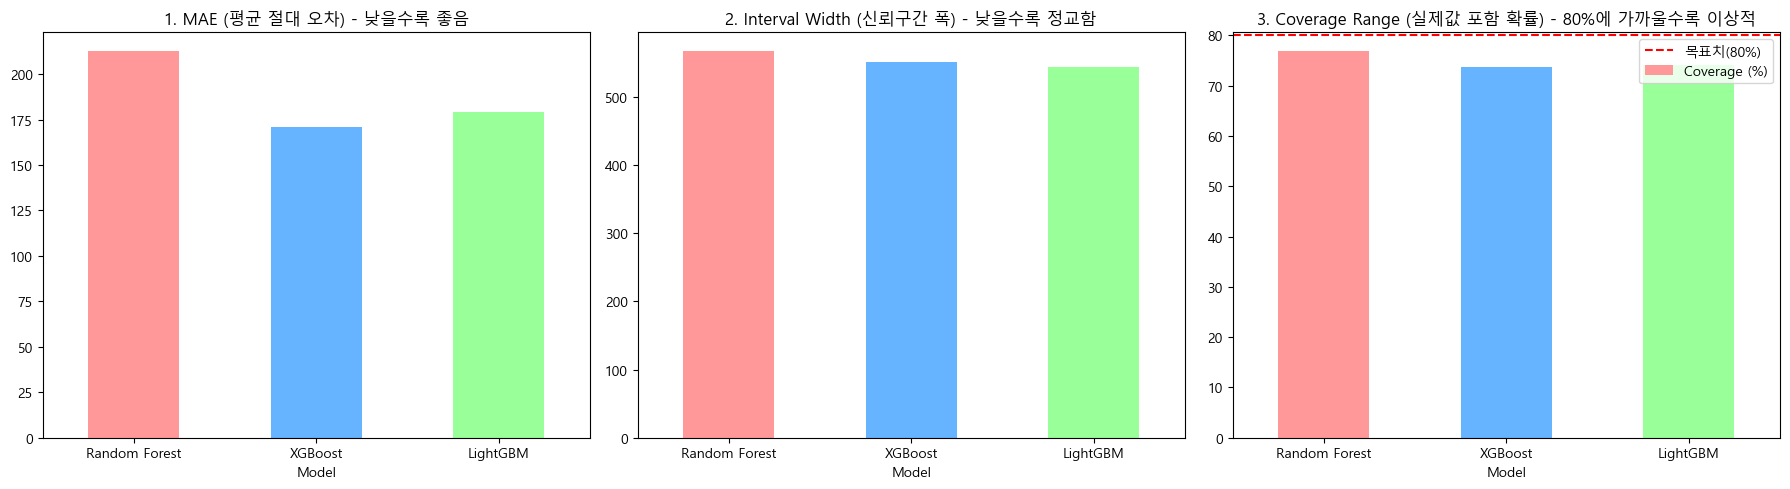

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 모델 임포트
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치(Outlier) 제거
# ==========================================
df =pd.read_csv('./data/encar_feature_label_encoded.csv').dropna()

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

for col in ['현재가격_만원', '주행거리_km', '차량연령']:
    df = remove_outliers_iqr(df, col)

# ==========================================
# 2. 데이터 전처리 (로그 변환 및 변수 분리)
# ==========================================
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])
df['log_model_avg_price'] = np.log1p(df['모델_평균가_TE'])

cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', '모델_평균가_TE', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. 3대 트리 모델 셋업 (중앙값 및 10%, 90% 분위수 예측)
# ==========================================
print("🚀 3대 트리 모델별 상세 학습 및 평가를 시작합니다...\n")
results = []
y_test_orig = np.expm1(y_test)

# --- (1) Random Forest ---
print("[Random Forest] 학습 중...")
rf_model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# RF는 모든 나무의 예측값을 모아 백분위수를 직접 계산합니다.
rf_pred_log = rf_model.predict(X_test)
rf_all_tree_preds = np.array([tree.predict(X_test.values) for tree in rf_model.estimators_])
rf_lower_log = np.percentile(rf_all_tree_preds, 10, axis=0)
rf_upper_log = np.percentile(rf_all_tree_preds, 90, axis=0)

rf_pred = np.expm1(rf_pred_log)
rf_lower = np.expm1(rf_lower_log)
rf_upper = np.expm1(rf_upper_log)

results.append({
    'Model': 'Random Forest',
    'R2 Score (%)': r2_score(y_test, rf_pred_log) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, rf_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, rf_pred)),
    'Range (Max-Min)': np.max(rf_pred) - np.min(rf_pred),
    'Interval Width (만원)': np.mean(rf_upper - rf_lower),
    'Coverage (%)': np.mean((y_test_orig >= rf_lower) & (y_test_orig <= rf_upper)) * 100
})

# --- (2) XGBoost ---
print("[XGBoost] 학습 중...")
# 중앙값 모델
xgb_model = XGBRegressor(objective='reg:absoluteerror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = np.expm1(xgb_model.predict(X_test))

# 하위 10%, 상위 90% 모델 (Quantile Error 지원 최신 버전용. 미지원 시 오류 방지용 sklearn GBM 대체)
try:
    xgb_lower = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
    xgb_upper = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
    xgb_lower.fit(X_train, y_train)
    xgb_upper.fit(X_train, y_train)
    pred_lower_xgb = np.expm1(xgb_lower.predict(X_test))
    pred_upper_xgb = np.expm1(xgb_upper.predict(X_test))
except:
    from sklearn.ensemble import GradientBoostingRegressor
    xgb_lower = GradientBoostingRegressor(loss='quantile', alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
    xgb_upper = GradientBoostingRegressor(loss='quantile', alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
    xgb_lower.fit(X_train, y_train)
    xgb_upper.fit(X_train, y_train)
    pred_lower_xgb = np.expm1(xgb_lower.predict(X_test))
    pred_upper_xgb = np.expm1(xgb_upper.predict(X_test))

results.append({
    'Model': 'XGBoost',
    'R2 Score (%)': r2_score(y_test, np.log1p(xgb_pred)) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, xgb_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, xgb_pred)),
    'Range (Max-Min)': np.max(xgb_pred) - np.min(xgb_pred),
    'Interval Width (만원)': np.mean(pred_upper_xgb - pred_lower_xgb),
    'Coverage (%)': np.mean((y_test_orig >= pred_lower_xgb) & (y_test_orig <= pred_upper_xgb)) * 100
})

# --- (3) LightGBM ---
print("[LightGBM] 학습 중...")
lgb_model = LGBMRegressor(objective='quantile', alpha=0.5, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
lgb_lower = LGBMRegressor(objective='quantile', alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
lgb_upper = LGBMRegressor(objective='quantile', alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)

lgb_model.fit(X_train, y_train)
lgb_lower.fit(X_train, y_train)
lgb_upper.fit(X_train, y_train)

lgb_pred = np.expm1(lgb_model.predict(X_test))
pred_lower_lgb = np.expm1(lgb_lower.predict(X_test))
pred_upper_lgb = np.expm1(lgb_upper.predict(X_test))

results.append({
    'Model': 'LightGBM',
    'R2 Score (%)': r2_score(y_test, np.log1p(lgb_pred)) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, lgb_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, lgb_pred)),
    'Range (Max-Min)': np.max(lgb_pred) - np.min(lgb_pred),
    'Interval Width (만원)': np.mean(pred_upper_lgb - pred_lower_lgb),
    'Coverage (%)': np.mean((y_test_orig >= pred_lower_lgb) & (y_test_orig <= pred_upper_lgb)) * 100
})

# ==========================================
# 4. 결과 출력 및 시각화
# ==========================================
results_df = pd.DataFrame(results).set_index('Model')

print("\n=========================================================================================")
print("🏆 모델별 종합 성능, 구간 폭(Width), 그리고 Coverage(실제값 포함 확률) 비교 (단위: 만원)")
print("=========================================================================================")
print(results_df.applymap(lambda x: f"{x:,.1f}").to_string())
print("=========================================================================================\n")

# 막대 그래프 3분할 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MAE 그래프
results_df['MAE (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[0])
axes[0].set_title('1. MAE (평균 절대 오차) - 낮을수록 좋음')
axes[0].tick_params(axis='x', rotation=0)

# 2. Interval Width 그래프
results_df['Interval Width (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[1])
axes[1].set_title('2. Interval Width (신뢰구간 폭) - 낮을수록 정교함')
axes[1].tick_params(axis='x', rotation=0)

# 3. Coverage 그래프
results_df['Coverage (%)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[2])
axes[2].set_title('3. Coverage Range (실제값 포함 확률) - 80%에 가까울수록 이상적')
axes[2].tick_params(axis='x', rotation=0)
axes[2].axhline(y=80, color='red', linestyle='--', label='목표치(80%)')
axes[2].legend()

plt.tight_layout()
plt.show()

🚀 [평균가 변수 제거됨] 순수 스펙 기반 3대 트리 모델 학습을 시작합니다...

[Random Forest] 학습 중...
[XGBoost] 학습 중...
[LightGBM] 학습 중...

🏆 모델별 종합 성능, 구간 폭(Width), 그리고 Coverage(실제값 포함 확률) 비교 (단위: 만원)
              R2 Score (%) MAE (만원) RMSE (만원) Range (Max-Min) Interval Width (만원) Coverage (%)
Model                                                                                         
Random Forest         95.0    204.8     331.9         4,954.6               608.8         75.9
XGBoost               95.3    192.6     309.2         5,276.3               604.5         75.6
LightGBM              95.1    197.8     315.4         5,260.5               580.6         75.5



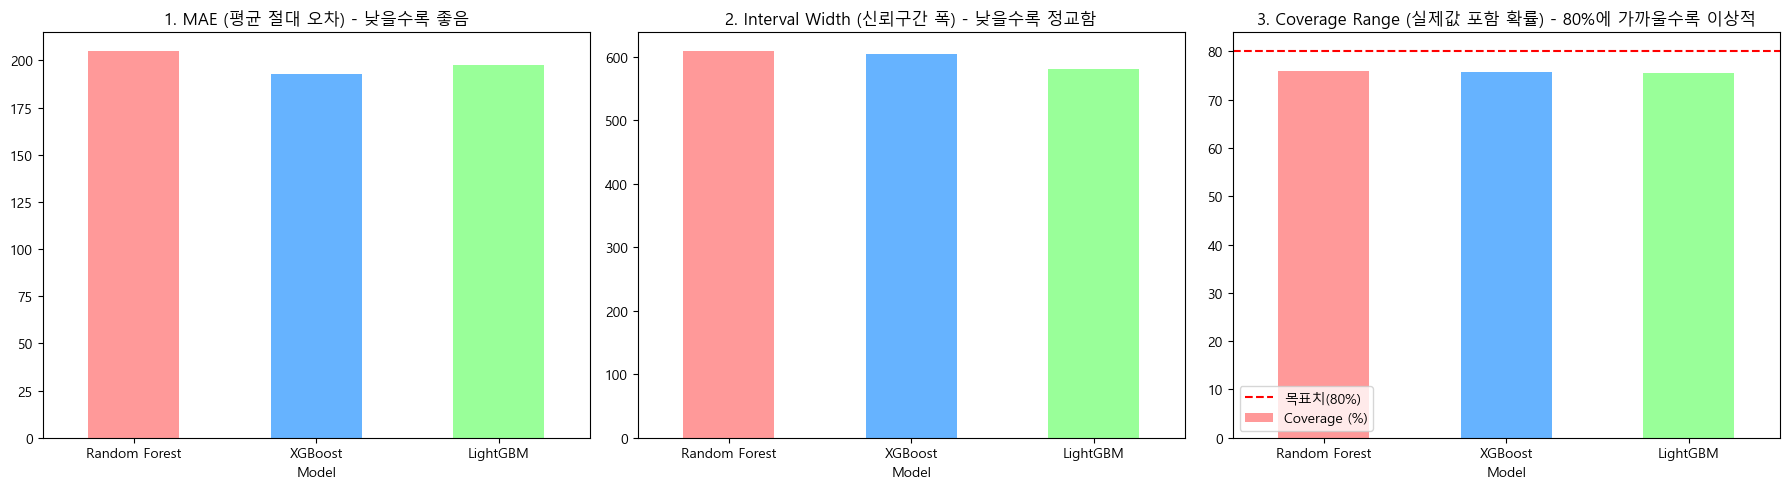

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 모델 임포트
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치(Outlier) 제거
# ==========================================
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv').dropna()

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

for col in ['현재가격_만원', '주행거리_km', '차량연령']:
    df = remove_outliers_iqr(df, col)

# ==========================================
# 2. 데이터 전처리 (로그 변환 및 변수 분리)
# ==========================================
# 가격, 주행거리, 배기량만 로그 변환 (모델_평균가는 제외)
df['log_price'] = np.log1p(df['현재가격_만원'])
df['log_mileage'] = np.log1p(df['주행거리_km'])
df['log_displacement'] = np.log1p(df['배기량_cc'])

# 독립변수(X)를 만들 때 '모델_평균가_TE'를 완전히 버립니다.
cols_to_drop = ['매물ID', '모델', '현재가격_만원', '주행거리_km', '배기량_cc', 'log_price']
X = df.drop(columns=cols_to_drop)
y = df['log_price']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. 3대 트리 모델 셋업 (중앙값 및 10%, 90% 분위수 예측)
# ==========================================
print("🚀 [평균가 변수 제거됨] 순수 스펙 기반 3대 트리 모델 학습을 시작합니다...\n")
results = []
y_test_orig = np.expm1(y_test)

# --- (1) Random Forest ---
print("[Random Forest] 학습 중...")
rf_model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred_log = rf_model.predict(X_test)
rf_all_tree_preds = np.array([tree.predict(X_test.values) for tree in rf_model.estimators_])
rf_lower_log = np.percentile(rf_all_tree_preds, 10, axis=0)
rf_upper_log = np.percentile(rf_all_tree_preds, 90, axis=0)

rf_pred = np.expm1(rf_pred_log)
rf_lower = np.expm1(rf_lower_log)
rf_upper = np.expm1(rf_upper_log)

results.append({
    'Model': 'Random Forest',
    'R2 Score (%)': r2_score(y_test, rf_pred_log) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, rf_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, rf_pred)),
    'Range (Max-Min)': np.max(rf_pred) - np.min(rf_pred),
    'Interval Width (만원)': np.mean(rf_upper - rf_lower),
    'Coverage (%)': np.mean((y_test_orig >= rf_lower) & (y_test_orig <= rf_upper)) * 100
})

# --- (2) XGBoost ---
print("[XGBoost] 학습 중...")
xgb_model = XGBRegressor(objective='reg:absoluteerror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = np.expm1(xgb_model.predict(X_test))

# XGBoost 분위수 예측 (호환성을 위해 GradientBoostingRegressor로 안전하게 대체)
from sklearn.ensemble import GradientBoostingRegressor
xgb_lower = GradientBoostingRegressor(loss='quantile', alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_upper = GradientBoostingRegressor(loss='quantile', alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_lower.fit(X_train, y_train)
xgb_upper.fit(X_train, y_train)
pred_lower_xgb = np.expm1(xgb_lower.predict(X_test))
pred_upper_xgb = np.expm1(xgb_upper.predict(X_test))

results.append({
    'Model': 'XGBoost',
    'R2 Score (%)': r2_score(y_test, np.log1p(xgb_pred)) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, xgb_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, xgb_pred)),
    'Range (Max-Min)': np.max(xgb_pred) - np.min(xgb_pred),
    'Interval Width (만원)': np.mean(pred_upper_xgb - pred_lower_xgb),
    'Coverage (%)': np.mean((y_test_orig >= pred_lower_xgb) & (y_test_orig <= pred_upper_xgb)) * 100
})

# --- (3) LightGBM ---
print("[LightGBM] 학습 중...")
lgb_model = LGBMRegressor(objective='quantile', alpha=0.5, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
lgb_lower = LGBMRegressor(objective='quantile', alpha=0.1, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
lgb_upper = LGBMRegressor(objective='quantile', alpha=0.9, n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)

lgb_model.fit(X_train, y_train)
lgb_lower.fit(X_train, y_train)
lgb_upper.fit(X_train, y_train)

lgb_pred = np.expm1(lgb_model.predict(X_test))
pred_lower_lgb = np.expm1(lgb_lower.predict(X_test))
pred_upper_lgb = np.expm1(lgb_upper.predict(X_test))

results.append({
    'Model': 'LightGBM',
    'R2 Score (%)': r2_score(y_test, np.log1p(lgb_pred)) * 100,
    'MAE (만원)': mean_absolute_error(y_test_orig, lgb_pred),
    'RMSE (만원)': np.sqrt(mean_squared_error(y_test_orig, lgb_pred)),
    'Range (Max-Min)': np.max(lgb_pred) - np.min(lgb_pred),
    'Interval Width (만원)': np.mean(pred_upper_lgb - pred_lower_lgb),
    'Coverage (%)': np.mean((y_test_orig >= pred_lower_lgb) & (y_test_orig <= pred_upper_lgb)) * 100
})

# ==========================================
# 4. 결과 출력 및 시각화
# ==========================================
results_df = pd.DataFrame(results).set_index('Model')

print("\n=========================================================================================")
print("🏆 모델별 종합 성능, 구간 폭(Width), 그리고 Coverage(실제값 포함 확률) 비교 (단위: 만원)")
print("=========================================================================================")
print(results_df.applymap(lambda x: f"{x:,.1f}").to_string())
print("=========================================================================================\n")

# 막대 그래프 3분할 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MAE 그래프
results_df['MAE (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[0])
axes[0].set_title('1. MAE (평균 절대 오차) - 낮을수록 좋음')
axes[0].tick_params(axis='x', rotation=0)

# 2. Interval Width 그래프
results_df['Interval Width (만원)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[1])
axes[1].set_title('2. Interval Width (신뢰구간 폭) - 낮을수록 정교함')
axes[1].tick_params(axis='x', rotation=0)

# 3. Coverage 그래프
results_df['Coverage (%)'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=axes[2])
axes[2].set_title('3. Coverage Range (실제값 포함 확률) - 80%에 가까울수록 이상적')
axes[2].tick_params(axis='x', rotation=0)
axes[2].axhline(y=80, color='red', linestyle='--', label='목표치(80%)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss

# 사용할 3가지 모델
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor # pip install quantile-forest

# 1. 데이터 로드 및 전처리
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')
df = df.drop(columns=['매물ID', '모델'])

# 로그 변환 (로그 변환 후 역변환은 최종 평가 시 진행)
large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc']
for col in large_num_cols:
    df[f'{col}_log'] = np.log1p(df[col])

X = df.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc'])
y = df['현재가격_만원_log']

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 평가를 위한 실제 정답 역변환 (만원 단위)
y_test_real = np.expm1(y_test)

# 2. 모델 학습
quantiles = [0.1, 0.5, 0.9]
models_lgbm, models_xgb = {}, {}

print("=== 모델 학습 시작 ===")
for q in quantiles:
    # LightGBM
    lgbm = LGBMRegressor(objective='quantile', alpha=q, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    # XGBoost
    xgb = XGBRegressor(objective='reg:quantileerror', quantile_alpha=q, random_state=42)
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

# Random Forest
qrf = RandomForestQuantileRegressor(random_state=42)
qrf.fit(X_train, y_train)
print("=== 모델 학습 완료 ===\n")

# 3. 모델 평가 함수 정의
def evaluate_quantile_model(model_name, y_true, preds_dict):
    """
    preds_dict: {0.1: pred_10, 0.5: pred_50, 0.9: pred_90} 형태의 역변환된 예측값 딕셔너리
    """
    print(f"[{model_name} 평가 결과]")
    
    # 1) Pinball Loss 계산 (각 분위수별)
    for q in quantiles:
        # scikit-learn의 mean_pinball_loss 사용
        p_loss = mean_pinball_loss(y_true, preds_dict[q], alpha=q)
        print(f" - Pinball Loss (q={q}): {p_loss:.2f}")
    
    # 2) 구간 커버리지 (Coverage) 및 구간 폭 (Interval Width) 계산
    # 하위 10% ~ 상위 90% 사이에 실제 값이 존재하는 비율 (이상적 커버리지는 80%)
    coverage = np.mean((y_true >= preds_dict[0.1]) & (y_true <= preds_dict[0.9]))
    avg_width = np.mean(preds_dict[0.9] - preds_dict[0.1])
    print(f" - 80% Prediction Interval Coverage: {coverage*100:.2f}% (목표: 약 80%)")
    print(f" - Average Interval Width (구간 평균 폭): {avg_width:.0f} 만원")
    
    # 3) MAE (중앙값 기준 실제 오차)
    mae = mean_absolute_error(y_true, preds_dict[0.5])
    print(f" - Median (q=0.5) MAE: {mae:.2f} 만원\n")

# 4. 각 모델별 예측 및 평가 수행
# 4.1 LightGBM 예측
preds_lgbm = {q: np.expm1(models_lgbm[q].predict(X_test)) for q in quantiles}
evaluate_quantile_model("LightGBM", y_test_real, preds_lgbm)

# 4.2 XGBoost 예측
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}
evaluate_quantile_model("XGBoost", y_test_real, preds_xgb)

# 4.3 Random Forest (Quantile Forest) 예측
# QRF는 한 번에 예측 가능
preds_qrf_log = qrf.predict(X_test, quantiles=quantiles)
preds_qrf = {
    0.1: np.expm1(preds_qrf_log[:, 0]),
    0.5: np.expm1(preds_qrf_log[:, 1]),
    0.9: np.expm1(preds_qrf_log[:, 2])
}
evaluate_quantile_model("Random Forest (Quantile)", y_test_real, preds_qrf)

=== 모델 학습 시작 ===
=== 모델 학습 완료 ===

[LightGBM 평가 결과]
 - Pinball Loss (q=0.1): 51.47
 - Pinball Loss (q=0.5): 116.00
 - Pinball Loss (q=0.9): 64.67
 - 80% Prediction Interval Coverage: 74.84% (목표: 약 80%)
 - Average Interval Width (구간 평균 폭): 683 만원
 - Median (q=0.5) MAE: 231.99 만원

[XGBoost 평가 결과]
 - Pinball Loss (q=0.1): 50.27
 - Pinball Loss (q=0.5): 116.35
 - Pinball Loss (q=0.9): 67.20
 - 80% Prediction Interval Coverage: 72.32% (목표: 약 80%)
 - Average Interval Width (구간 평균 폭): 649 만원
 - Median (q=0.5) MAE: 232.69 만원

[Random Forest (Quantile) 평가 결과]
 - Pinball Loss (q=0.1): 52.19
 - Pinball Loss (q=0.5): 119.96
 - Pinball Loss (q=0.9): 68.12
 - 80% Prediction Interval Coverage: 77.14% (목표: 약 80%)
 - Average Interval Width (구간 평균 폭): 707 만원
 - Median (q=0.5) MAE: 239.93 만원



In [14]:
!pip install quantile-forest


   ---------------------------------------- 0.0/685.5 kB ? eta -:--:--
   --------------- ------------------------ 262.1/685.5 kB ? eta -:--:--
   ---------------------------------------- 685.5/685.5 kB 2.3 MB/s  0:00:00


=== 분위수 회귀 모델 학습 시작 ===
=== 학습 완료 ===



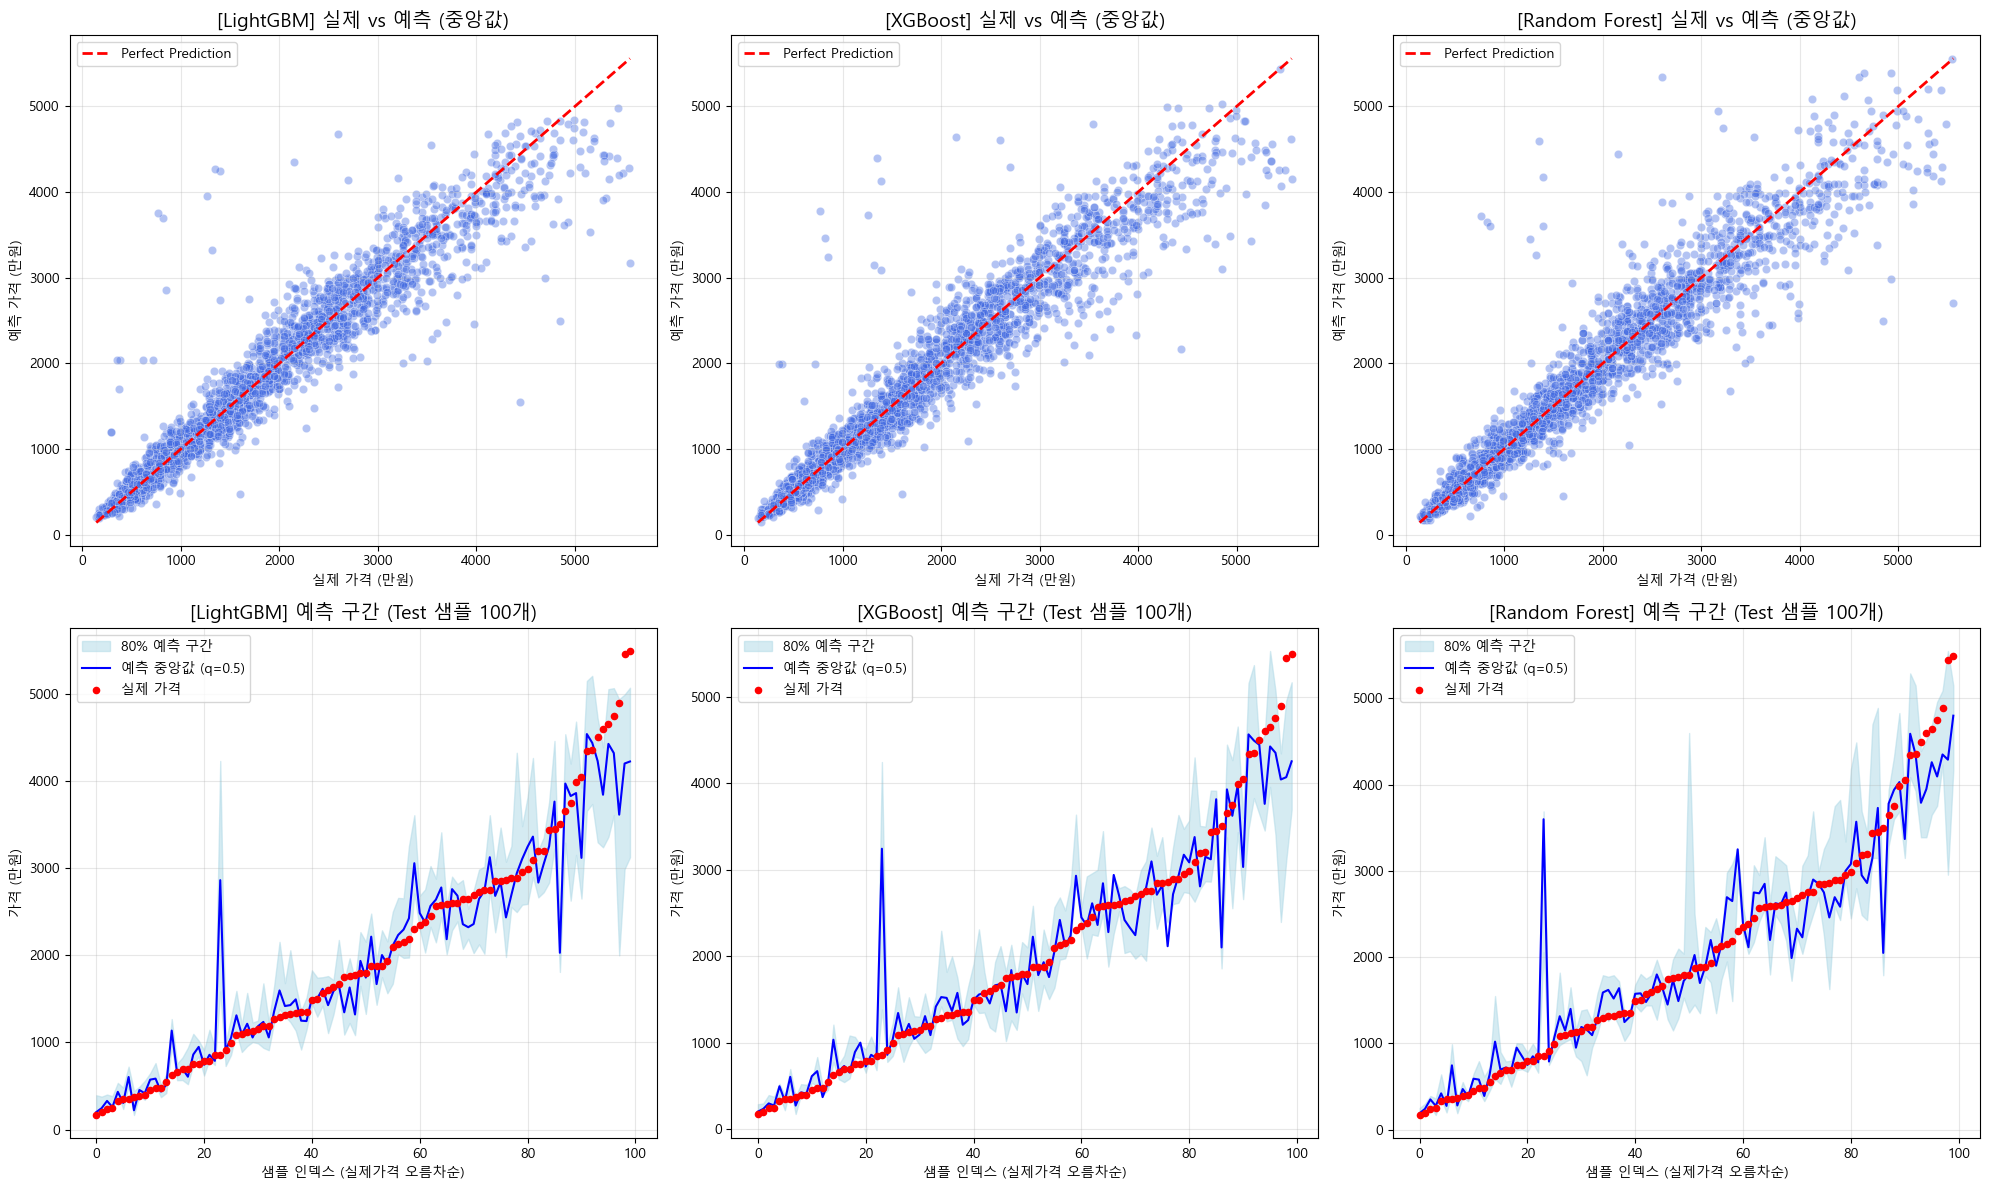

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss

# 모델 라이브러리
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor # pip install quantile-forest

# 시각화 한글 폰트 설정
plt.rc('font', family='Malgun Gothic') # Mac 사용자는 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치 제거 (IQR)
# ==========================================
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# ==========================================
# 2. 전처리 (로그 변환 및 불필요 컬럼 제거)
# ==========================================
df_clean = df_clean.drop(columns=['매물ID', '모델'])

large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc']
for col in large_num_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# ==========================================
# 3. 모델 학습
# ==========================================
quantiles = [0.1, 0.5, 0.9]
models_lgbm, models_xgb = {}, {}

print("=== 분위수 회귀 모델 학습 시작 ===")
for q in quantiles:
    lgbm = LGBMRegressor(objective='quantile', alpha=q, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    xgb = XGBRegressor(objective='reg:quantileerror', quantile_alpha=q, random_state=42)
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

qrf = RandomForestQuantileRegressor(random_state=42)
qrf.fit(X_train, y_train)
print("=== 학습 완료 ===\n")

# ==========================================
# 4. 예측 수행
# ==========================================
preds_lgbm = {q: np.expm1(models_lgbm[q].predict(X_test)) for q in quantiles}
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}

preds_qrf_log = qrf.predict(X_test, quantiles=quantiles)
preds_qrf = {
    0.1: np.expm1(preds_qrf_log[:, 0]),
    0.5: np.expm1(preds_qrf_log[:, 1]),
    0.9: np.expm1(preds_qrf_log[:, 2])
}

# ==========================================
# 5. 3개 모델 종합 시각화 (2x3 배열)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_info = [
    ("LightGBM", preds_lgbm),
    ("XGBoost", preds_xgb),
    ("Random Forest", preds_qrf)
]

# [Row 1] 실제값 vs 예측값 (Scatter Plot)
for i, (name, preds) in enumerate(models_info):
    ax = axes[0, i]
    sns.scatterplot(x=y_test_real, y=preds[0.5], alpha=0.4, color='royalblue', ax=ax)
    ax.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 
             'r--', lw=2, label='Perfect Prediction')
    ax.set_title(f"[{name}] 실제 vs 예측 (중앙값)", fontsize=14)
    ax.set_xlabel("실제 가격 (만원)")
    ax.set_ylabel("예측 가격 (만원)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# [Row 2] 예측 구간 시각화 (Prediction Interval)
# 공정한 비교를 위해 세 모델 모두 동일한 100개 샘플 사용
np.random.seed(42)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
y_real_sample = y_test_real.iloc[sample_idx].values

# 세 모델의 그래프를 동일한 기준으로 보기 위해 "실제 가격" 기준으로 오름차순 정렬
sort_idx = np.argsort(y_real_sample)
y_real_sample_sorted = y_real_sample[sort_idx]
x_axis = np.arange(100)

for i, (name, preds) in enumerate(models_info):
    ax = axes[1, i]
    
    # 샘플 추출 및 정렬 적용
    pred_10_sample = preds[0.1][sample_idx][sort_idx]
    pred_50_sample = preds[0.5][sample_idx][sort_idx]
    pred_90_sample = preds[0.9][sample_idx][sort_idx]
    
    # 80% 구간 색칠 (하위 10% ~ 상위 90%)
    ax.fill_between(x_axis, pred_10_sample, pred_90_sample, color='lightblue', alpha=0.5, label='80% 예측 구간')
    # 중앙값 선
    ax.plot(x_axis, pred_50_sample, 'b-', lw=1.5, label='예측 중앙값 (q=0.5)')
    # 실제값 점
    ax.scatter(x_axis, y_real_sample_sorted, color='red', s=20, zorder=5, label='실제 가격')
    
    ax.set_title(f"[{name}] 예측 구간 (Test 샘플 100개)", fontsize=14)
    ax.set_xlabel("샘플 인덱스 (실제가격 오름차순)")
    ax.set_ylabel("가격 (만원)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 모델 학습 진행 중 ===
=== 학습 완료 ===

=================== [ 모델별 성능 지표 종합 표 ] ===================
          모델명  MAE (만원)  Pinball_Loss (q=0.1)  Pinball_Loss (q=0.5)  Pinball_Loss (q=0.9)  80% 구간 커버리지 (%)  평균 구간 폭 (만원)
     LightGBM    194.18                 46.31                 97.09                 48.37            76.53        598.91
      XGBoost    201.21                 45.65                100.60                 49.76            73.65        578.00
Random Forest    203.18                 46.38                101.59                 49.80            79.52        642.25



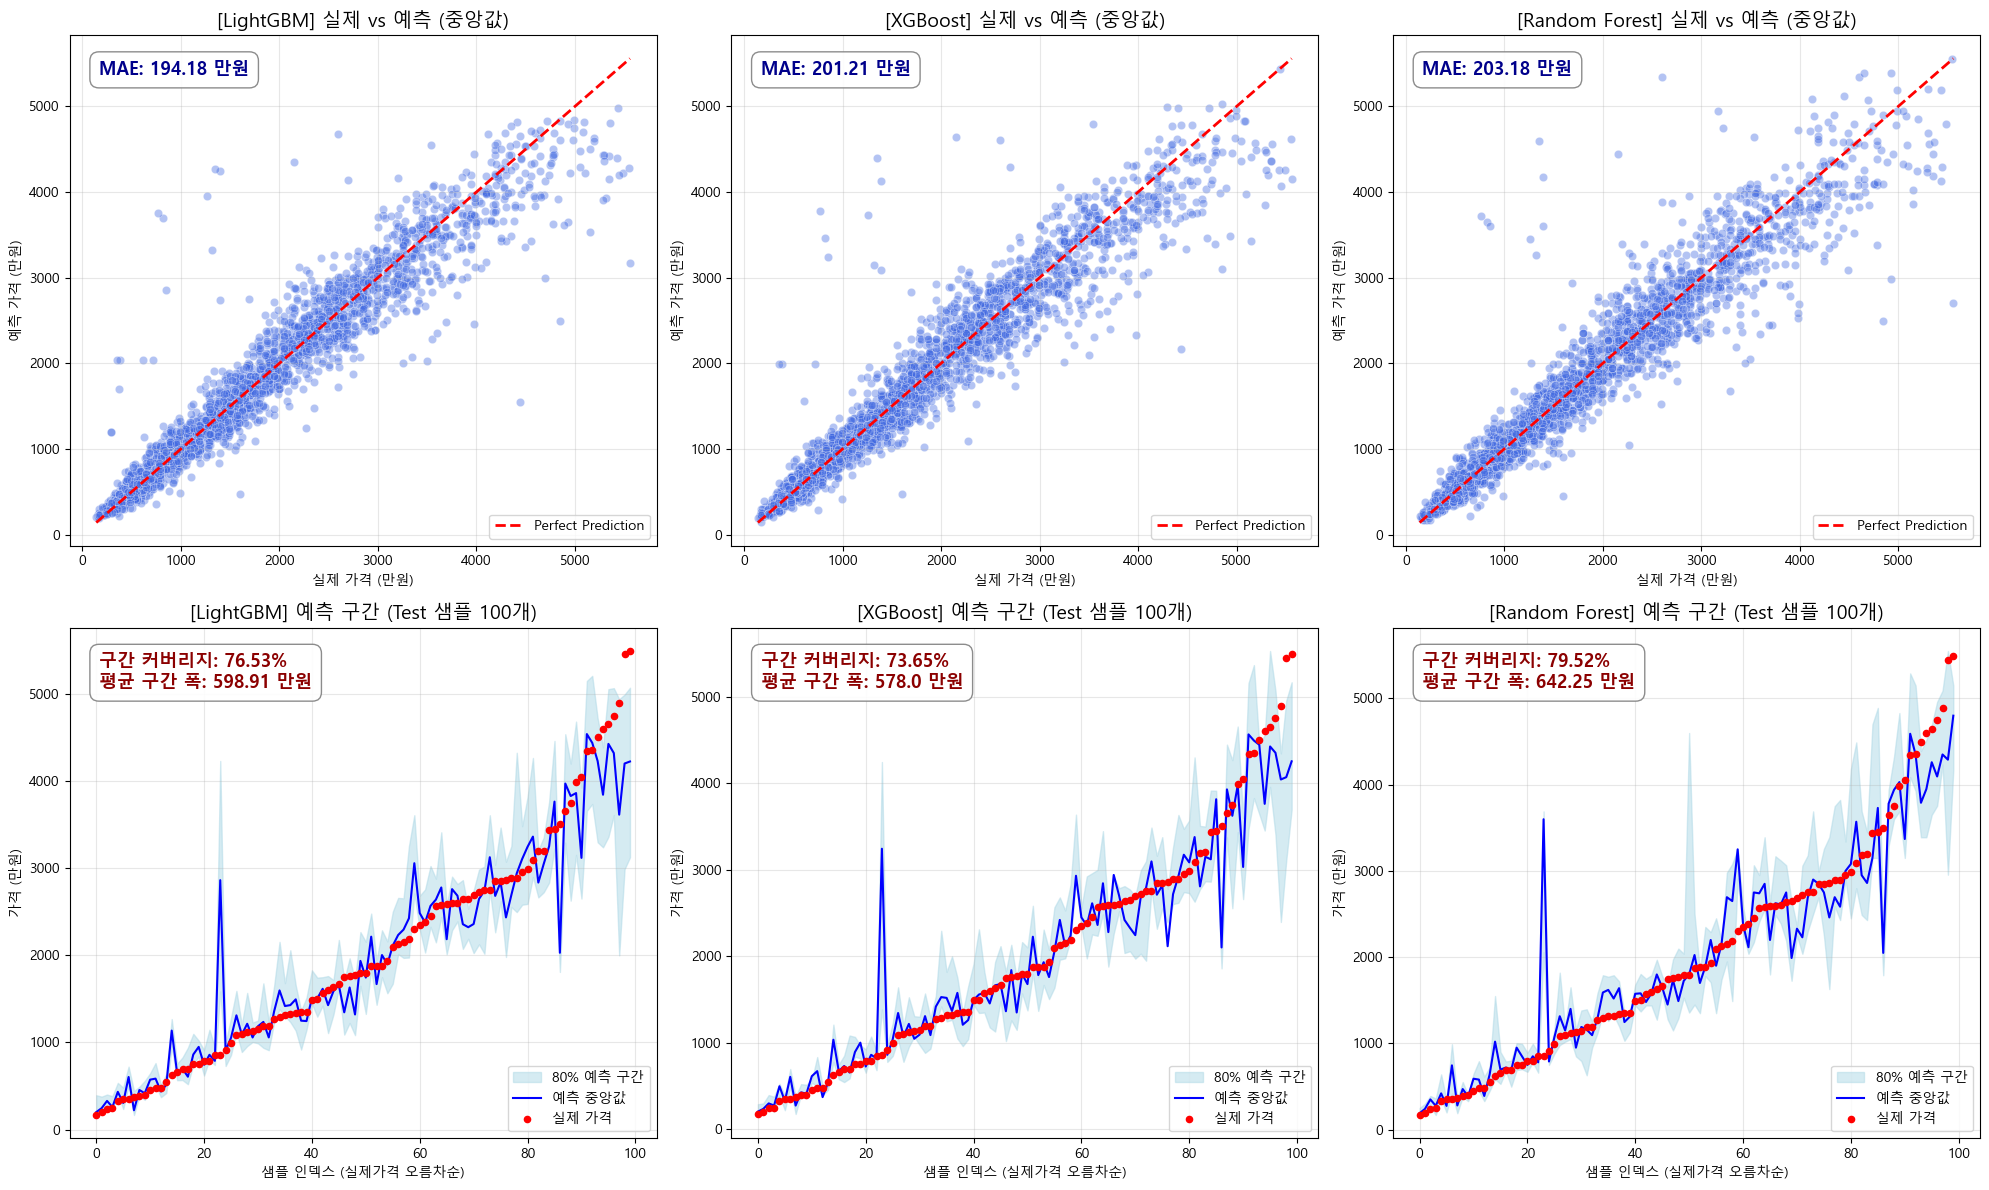

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss

# 모델 라이브러리
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor # pip install quantile-forest

# 시각화 한글 폰트 설정
plt.rc('font', family='Malgun Gothic') # Mac 사용자는 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 전처리 (이상치 제거 포함)
# ==========================================
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# 이상치 제거
df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# 불필요 컬럼 제거 및 로그 변환
df_clean = df_clean.drop(columns=['매물ID', '모델'])
large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc']
for col in large_num_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# ==========================================
# 2. 모델 학습
# ==========================================
quantiles = [0.1, 0.5, 0.9]
models_lgbm, models_xgb = {}, {}

print("=== 모델 학습 진행 중 ===")
for q in quantiles:
    lgbm = LGBMRegressor(objective='quantile', alpha=q, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    xgb = XGBRegressor(objective='reg:quantileerror', quantile_alpha=q, random_state=42)
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

qrf = RandomForestQuantileRegressor(random_state=42)
qrf.fit(X_train, y_train)
print("=== 학습 완료 ===\n")

# ==========================================
# 3. 모델 예측 및 역변환
# ==========================================
preds_lgbm = {q: np.expm1(models_lgbm[q].predict(X_test)) for q in quantiles}
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}

preds_qrf_log = qrf.predict(X_test, quantiles=quantiles)
preds_qrf = {
    0.1: np.expm1(preds_qrf_log[:, 0]),
    0.5: np.expm1(preds_qrf_log[:, 1]),
    0.9: np.expm1(preds_qrf_log[:, 2])
}

models_info = [
    ("LightGBM", preds_lgbm),
    ("XGBoost", preds_xgb),
    ("Random Forest", preds_qrf)
]

# ==========================================
# 4. 종합 성능 지표(Metrics) 추출 및 출력
# ==========================================
metrics_list = []

for name, preds in models_info:
    # 지표 계산
    mae = mean_absolute_error(y_test_real, preds[0.5])
    pb_10 = mean_pinball_loss(y_test_real, preds[0.1], alpha=0.1)
    pb_50 = mean_pinball_loss(y_test_real, preds[0.5], alpha=0.5)
    pb_90 = mean_pinball_loss(y_test_real, preds[0.9], alpha=0.9)
    
    coverage = np.mean((y_test_real >= preds[0.1]) & (y_test_real <= preds[0.9])) * 100
    avg_width = np.mean(preds[0.9] - preds[0.1])
    
    # 딕셔너리 형태로 저장
    metrics_list.append({
        '모델명': name,
        'MAE (만원)': round(mae, 2),
        'Pinball_Loss (q=0.1)': round(pb_10, 2),
        'Pinball_Loss (q=0.5)': round(pb_50, 2),
        'Pinball_Loss (q=0.9)': round(pb_90, 2),
        '80% 구간 커버리지 (%)': round(coverage, 2),
        '평균 구간 폭 (만원)': round(avg_width, 2)
    })

# DataFrame으로 변환 후 출력
metrics_df = pd.DataFrame(metrics_list)
print("=================== [ 모델별 성능 지표 종합 표 ] ===================")
print(metrics_df.to_string(index=False))
print("====================================================================\n")


# ==========================================
# 5. 수치가 포함된 3개 모델 종합 시각화 (2x3)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')

# [Row 1] 실제값 vs 예측값 (Scatter Plot)
for i, (name, preds) in enumerate(models_info):
    ax = axes[0, i]
    sns.scatterplot(x=y_test_real, y=preds[0.5], alpha=0.4, color='royalblue', ax=ax)
    ax.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 
             'r--', lw=2, label='Perfect Prediction')
    
    mae_val = metrics_df.loc[metrics_df['모델명'] == name, 'MAE (만원)'].values[0]
    text_str = f"MAE: {mae_val} 만원"
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=13, 
            verticalalignment='top', bbox=props, fontweight='bold', color='darkblue')

    ax.set_title(f"[{name}] 실제 vs 예측 (중앙값)", fontsize=14)
    ax.set_xlabel("실제 가격 (만원)")
    ax.set_ylabel("예측 가격 (만원)")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

# [Row 2] 예측 구간 시각화 (Prediction Interval)
np.random.seed(42)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
y_real_sample = y_test_real.iloc[sample_idx].values

sort_idx = np.argsort(y_real_sample)
y_real_sample_sorted = y_real_sample[sort_idx]
x_axis = np.arange(100)

for i, (name, preds) in enumerate(models_info):
    ax = axes[1, i]
    
    pred_10_sample = preds[0.1][sample_idx][sort_idx]
    pred_50_sample = preds[0.5][sample_idx][sort_idx]
    pred_90_sample = preds[0.9][sample_idx][sort_idx]
    
    ax.fill_between(x_axis, pred_10_sample, pred_90_sample, color='lightblue', alpha=0.5, label='80% 예측 구간')
    ax.plot(x_axis, pred_50_sample, 'b-', lw=1.5, label='예측 중앙값')
    ax.scatter(x_axis, y_real_sample_sorted, color='red', s=20, zorder=5, label='실제 가격')
    
    cov_val = metrics_df.loc[metrics_df['모델명'] == name, '80% 구간 커버리지 (%)'].values[0]
    width_val = metrics_df.loc[metrics_df['모델명'] == name, '평균 구간 폭 (만원)'].values[0]
    text_str2 = f"구간 커버리지: {cov_val}%\n평균 구간 폭: {width_val} 만원"
    
    ax.text(0.05, 0.95, text_str2, transform=ax.transAxes, fontsize=13, 
            verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

    ax.set_title(f"[{name}] 예측 구간 (Test 샘플 100개)", fontsize=14)
    ax.set_xlabel("샘플 인덱스 (실제가격 오름차순)")
    ax.set_ylabel("가격 (만원)")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 이상치 제거 (IQR 완화)
# ==========================================
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

# 극단적인 이상치만 제거하도록 multiplier를 1.5 -> 2.0으로 상향 조정 (데이터 손실 방지)
def remove_outliers_iqr(data, column, multiplier=2.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# ==========================================
# 2. 파생 변수 생성 및 인코딩
# ==========================================
# [중요] 타겟값이 들어가지 않은 순수 물리적 파생 변수 추가
df_clean['차량연령_보정'] = df_clean['차량연령'].replace(0, 1) # 0년차 분모 에러 방지
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / df_clean['차량연령_보정']
df_clean = df_clean.drop(columns=['차량연령_보정'])

# [중요] 모델명을 지우지 않고 One-Hot Encoding 적용 (더미 변수화)
df_clean = pd.get_dummies(df_clean, columns=['모델'], drop_first=True)
df_clean = df_clean.drop(columns=['매물ID'])

# ==========================================
# 3. 로그 변환 (기존 조건 유지)
# ==========================================
# 새로 추가된 연간_주행거리도 큰 수치이므로 로그 변환 대상에 포함
large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리']
for col in large_num_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc', '연간_주행거리'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# ==========================================
# 4. 모델 하이퍼파라미터 튜닝 학습
# ==========================================
quantiles = [0.1, 0.5, 0.9]
models_lgbm, models_xgb = {}, {}

print("=== 튜닝된 모델 학습 진행 중 ===")
for q in quantiles:
    # LightGBM: 학습률은 낮추고 트리 개수 증가
    lgbm = LGBMRegressor(
        objective='quantile', alpha=q, 
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    # XGBoost: 깊이 제한 및 정교한 학습 유도
    xgb = XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=q, 
        n_estimators=300, learning_rate=0.05, max_depth=6,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

# Random Forest: 트리 개수 증가 및 과적합 방지를 위해 min_samples_leaf=3 지정 (Coverage 상승 효과)
qrf = RandomForestQuantileRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
qrf.fit(X_train, y_train)
print("=== 학습 완료 ===\n")

# ==========================================
# 5. 예측 및 지표 평가
# ==========================================
preds_lgbm = {q: np.expm1(models_lgbm[q].predict(X_test)) for q in quantiles}
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}

preds_qrf_log = qrf.predict(X_test, quantiles=quantiles)
preds_qrf = {0.1: np.expm1(preds_qrf_log[:, 0]), 0.5: np.expm1(preds_qrf_log[:, 1]), 0.9: np.expm1(preds_qrf_log[:, 2])}

models_info = [("LightGBM", preds_lgbm), ("XGBoost", preds_xgb), ("Random Forest", preds_qrf)]
metrics_list = []

for name, preds in models_info:
    mae = mean_absolute_error(y_test_real, preds[0.5])
    pb_10 = mean_pinball_loss(y_test_real, preds[0.1], alpha=0.1)
    pb_50 = mean_pinball_loss(y_test_real, preds[0.5], alpha=0.5)
    pb_90 = mean_pinball_loss(y_test_real, preds[0.9], alpha=0.9)
    coverage = np.mean((y_test_real >= preds[0.1]) & (y_test_real <= preds[0.9])) * 100
    avg_width = np.mean(preds[0.9] - preds[0.1])
    
    metrics_list.append({
        '모델명': name,
        'MAE (만원)': round(mae, 2),
        'Pinball(q=0.5)': round(pb_50, 2),
        'Coverage (%)': round(coverage, 2),
        '구간 폭 (만원)': round(avg_width, 2)
    })

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df.to_string(index=False))

=== 튜닝된 모델 학습 진행 중 ===
=== 학습 완료 ===

          모델명  MAE (만원)  Pinball(q=0.5)  Coverage (%)  구간 폭 (만원)
     LightGBM    177.07           88.53         69.97 491.890000
      XGBoost    181.06           90.53         74.44 560.469971
Random Forest    195.02           97.51         83.78 690.980000


=== 고강도 튜닝 모델 학습 진행 중 ===
=== 학습 완료 ===

=================== [ 튜닝 후 성능 지표 종합 표 ] ===================
          모델명  MAE (만원)  Pinball(q=0.5)  Coverage (%)  구간 폭 (만원)
     LightGBM    170.34           85.17         75.76 570.000000
      XGBoost    166.04           83.02         82.20 692.710022
Random Forest    190.98           95.49         90.63 887.270000



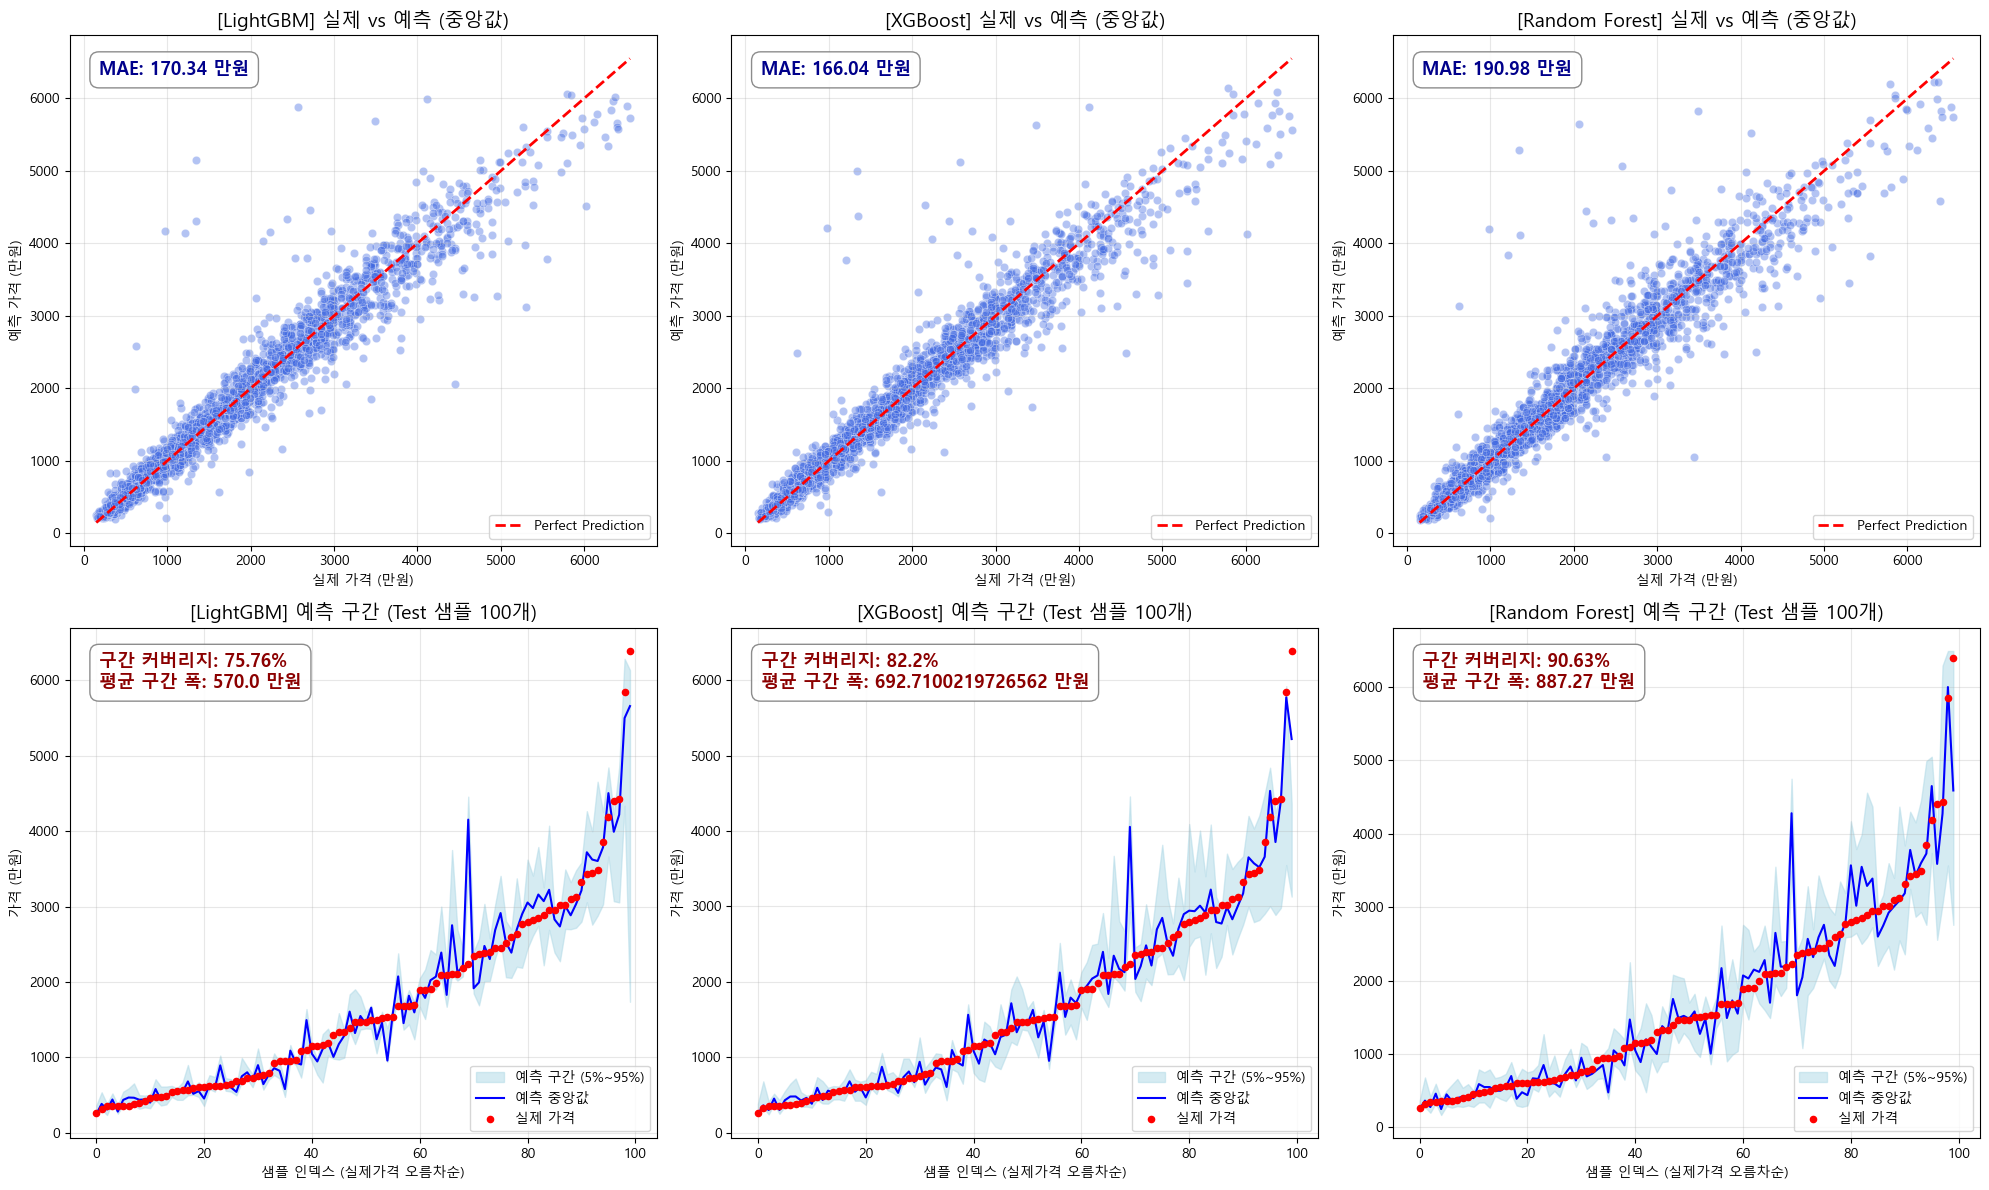

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor

# 시각화 한글 폰트 설정
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=2.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# 파생 변수 및 인코딩
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1)
df_clean = pd.get_dummies(df_clean, columns=['모델'], drop_first=True)
df_clean = df_clean.drop(columns=['매물ID'])
df_clean['차량연령_log'] = np.log1p(df_clean['차량연령'])

large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리']
for col in large_num_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# ==========================================
# 2. 고강도 튜닝 모델 학습
# ==========================================
quantiles = [0.05, 0.5, 0.95]
models_lgbm, models_xgb = {}, {}

print("=== 고강도 튜닝 모델 학습 진행 중 ===")
for q in quantiles:
    lgbm = LGBMRegressor(
        objective='quantile', alpha=q, n_estimators=800, learning_rate=0.03, 
        num_leaves=127, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    xgb = XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=q, n_estimators=800, 
        learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

qrf = RandomForestQuantileRegressor(n_estimators=300, min_samples_leaf=2, random_state=42)
qrf.fit(X_train, y_train)
print("=== 학습 완료 ===\n")

# ==========================================
# 3. 예측 및 지표 평가 DataFrame 생성
# ==========================================
preds_lgbm = {q: np.expm1(models_lgbm[q].predict(X_test)) for q in quantiles}
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}
preds_qrf_log = qrf.predict(X_test, quantiles=quantiles)
preds_qrf = {q: np.expm1(preds_qrf_log[:, i]) for i, q in enumerate(quantiles)}

models_info = [("LightGBM", preds_lgbm), ("XGBoost", preds_xgb), ("Random Forest", preds_qrf)]
metrics_list = []

for name, preds in models_info:
    mae = mean_absolute_error(y_test_real, preds[0.5])
    pb_50 = mean_pinball_loss(y_test_real, preds[0.5], alpha=0.5)
    coverage = np.mean((y_test_real >= preds[0.05]) & (y_test_real <= preds[0.95])) * 100
    avg_width = np.mean(preds[0.95] - preds[0.05])
    
    metrics_list.append({
        '모델명': name,
        'MAE (만원)': round(mae, 2),
        'Pinball(q=0.5)': round(pb_50, 2),
        'Coverage (%)': round(coverage, 2),
        '구간 폭 (만원)': round(avg_width, 2)
    })

metrics_df = pd.DataFrame(metrics_list)
print("=================== [ 튜닝 후 성능 지표 종합 표 ] ===================")
print(metrics_df.to_string(index=False))
print("=====================================================================\n")

# ==========================================
# 4. 수치가 포함된 3개 모델 종합 시각화 (2x3)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')

# [Row 1] 실제값 vs 예측값 (Scatter Plot)
for i, (name, preds) in enumerate(models_info):
    ax = axes[0, i]
    sns.scatterplot(x=y_test_real, y=preds[0.5], alpha=0.4, color='royalblue', ax=ax)
    ax.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 
             'r--', lw=2, label='Perfect Prediction')
    
    mae_val = metrics_df.loc[metrics_df['모델명'] == name, 'MAE (만원)'].values[0]
    text_str = f"MAE: {mae_val} 만원"
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=13, 
            verticalalignment='top', bbox=props, fontweight='bold', color='darkblue')

    ax.set_title(f"[{name}] 실제 vs 예측 (중앙값)", fontsize=14)
    ax.set_xlabel("실제 가격 (만원)")
    ax.set_ylabel("예측 가격 (만원)")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

# [Row 2] 예측 구간 시각화 (Prediction Interval)
np.random.seed(42)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
y_real_sample = y_test_real.iloc[sample_idx].values

sort_idx = np.argsort(y_real_sample)
y_real_sample_sorted = y_real_sample[sort_idx]
x_axis = np.arange(100)

for i, (name, preds) in enumerate(models_info):
    ax = axes[1, i]
    
    pred_05_sample = preds[0.05][sample_idx][sort_idx]
    pred_50_sample = preds[0.5][sample_idx][sort_idx]
    pred_95_sample = preds[0.95][sample_idx][sort_idx]
    
    # 5% ~ 95% 구간 색칠
    ax.fill_between(x_axis, pred_05_sample, pred_95_sample, color='lightblue', alpha=0.5, label='예측 구간 (5%~95%)')
    ax.plot(x_axis, pred_50_sample, 'b-', lw=1.5, label='예측 중앙값')
    ax.scatter(x_axis, y_real_sample_sorted, color='red', s=20, zorder=5, label='실제 가격')
    
    cov_val = metrics_df.loc[metrics_df['모델명'] == name, 'Coverage (%)'].values[0]
    width_val = metrics_df.loc[metrics_df['모델명'] == name, '구간 폭 (만원)'].values[0]
    text_str2 = f"구간 커버리지: {cov_val}%\n평균 구간 폭: {width_val} 만원"
    
    ax.text(0.05, 0.95, text_str2, transform=ax.transAxes, fontsize=13, 
            verticalalignment='top', bbox=props, fontweight='bold', color='darkred')

    ax.set_title(f"[{name}] 예측 구간 (Test 샘플 100개)", fontsize=14)
    ax.set_xlabel("샘플 인덱스 (실제가격 오름차순)")
    ax.set_ylabel("가격 (만원)")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import numpy as np
import warnings
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from quantile_forest import RandomForestQuantileRegressor # pip install quantile-forest 필요

warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 3개 모델 예측 엔진 구축
# ==========================================
print("데이터를 학습하여 3개의 AI 예측 엔진을 준비 중입니다. 잠시만 기다려주세요...\n")

df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=2.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

fill_values = {}
for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        fill_values[col] = df_clean[col].median()
    else:
        fill_values[col] = df_clean[col].mode()[0]

df_clean['보증만료_여부'] = ((df_clean['차량연령'] > 5) | (df_clean['주행거리_km'] > 100000)).astype(int)
df_clean['연식_주행거리_교호'] = (df_clean['차량연령'] + 1) * df_clean['주행거리_km']
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1)
df_clean['차량연령_log'] = np.log1p(df_clean['차량연령'])

df_clean = pd.get_dummies(df_clean, columns=['모델'], drop_first=True)
df_clean = df_clean.drop(columns=['매물ID'])

large_num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리', '연식_주행거리_교호']
for col in large_num_cols:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X_train = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc', '연간_주행거리', '연식_주행거리_교호', '차량연령'])
y_train = df_clean['현재가격_만원_log']
expected_cols = X_train.columns.tolist()

quantiles = [0.05, 0.5, 0.95]
models_lgbm = {}
models_xgb = {}

# [1] LightGBM & XGBoost 학습 (각 분위수별 독립 학습)
for q in quantiles:
    lgbm = LGBMRegressor(
        objective='quantile', alpha=q, 
        n_estimators=800, learning_rate=0.03, num_leaves=127, 
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    )
    lgbm.fit(X_train, y_train)
    models_lgbm[q] = lgbm
    
    xgb = XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=q, 
        n_estimators=800, learning_rate=0.03, max_depth=8, 
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

# [2] Random Forest 학습 (한 번에 학습)
qrf = RandomForestQuantileRegressor(n_estimators=300, min_samples_leaf=2, random_state=42)
qrf.fit(X_train, y_train)

print("✔ 3개 모델(LGBM, XGBoost, Random Forest) 엔진 준비 완료!\n")


# ==========================================
# 2. 통합 가격 계산 함수 정의
# ==========================================
def calculate_all_model_prices(car_info):
    user_df = pd.DataFrame([car_info])
    
    for col in fill_values.keys():
        if col not in user_df.columns and col not in ['매물ID', '현재가격_만원']:
            user_df[col] = fill_values[col]
            
    user_df['보증만료_여부'] = ((user_df['차량연령'] > 5) | (user_df['주행거리_km'] > 100000)).astype(int)
    user_df['연식_주행거리_교호'] = (user_df['차량연령'] + 1) * user_df['주행거리_km']
    user_df['연간_주행거리'] = user_df['주행거리_km'] / (user_df['차량연령'] + 1)
    user_df['차량연령_log'] = np.log1p(user_df['차량연령'])
    
    user_encoded = pd.get_dummies(user_df, columns=['모델'])
    
    large_cols_predict = ['주행거리_km', '배기량_cc', '연간_주행거리', '연식_주행거리_교호']
    for col in large_cols_predict:
        user_encoded[f'{col}_log'] = np.log1p(user_encoded[col])
        if col in user_encoded.columns:
            user_encoded = user_encoded.drop(columns=[col])
    user_encoded = user_encoded.drop(columns=['차량연령'], errors='ignore')
    
    for col in expected_cols:
        if col not in user_encoded.columns:
            user_encoded[col] = 0
            
    user_X = user_encoded[expected_cols]
    
    results = {}
    
    # [1] LightGBM 예측 및 정렬
    raw_lgbm = [np.expm1(models_lgbm[q].predict(user_X)[0]) for q in quantiles]
    results['LightGBM'] = sorted(raw_lgbm)
    
    # [2] XGBoost 예측 및 정렬
    raw_xgb = [np.expm1(models_xgb[q].predict(user_X)[0]) for q in quantiles]
    results['XGBoost'] = sorted(raw_xgb)
    
    # [3] Random Forest 예측 및 정렬
    rf_preds_log = qrf.predict(user_X, quantiles=quantiles)[0]
    raw_rf = [np.expm1(rf_preds_log[0]), np.expm1(rf_preds_log[1]), np.expm1(rf_preds_log[2])]
    results['Random Forest'] = sorted(raw_rf)
    
    return results


# ==========================================
# 3. ⭐ 차량 스펙 입력 및 3사 모델 결과 확인 ⭐
# ==========================================
my_car_info = {
    '모델': '제네시스',            
    '차량연령': 2,               
    '주행거리_km': 1972,        
    '배기량_cc': 3470,           
    '사고강도점수': 0,           
    '주요옵션_선루프': 1,        
    '주요옵션_내비게이션': 1, 
    '주요옵션_스마트키': 1,
    '주요옵션_열선시트': 1
}

# 계산 실행
prediction_results = calculate_all_model_prices(my_car_info)

# 결과 출력
print(f"==================================================")
print(f" 🚘 [{my_car_info['모델']}] 차량 스펙 AI 종합 예측 리포트")
print(f"    - 연식: {my_car_info['차량연령']}년 / 주행거리: {my_car_info['주행거리_km']:,}km")
print(f"==================================================\n")

for model_name, prices in prediction_results.items():
    print(f"🤖 [{model_name}] 예측 결과")
    print(f"   📉 급매가 (하위 5%)  : {int(prices[0]):,} 만원")
    print(f"   🎯 적정가 (중앙값)    : {int(prices[1]):,} 만원")
    print(f"   📈 상한가 (상위 5%)  : {int(prices[2]):,} 만원")
    print("-" * 50)

데이터를 학습하여 3개의 AI 예측 엔진을 준비 중입니다. 잠시만 기다려주세요...

✔ 3개 모델(LGBM, XGBoost, Random Forest) 엔진 준비 완료!

 🚘 [제네시스] 차량 스펙 AI 종합 예측 리포트
    - 연식: 2년 / 주행거리: 1,972km

🤖 [LightGBM] 예측 결과
   📉 급매가 (하위 5%)  : 3,693 만원
   🎯 적정가 (중앙값)    : 5,042 만원
   📈 상한가 (상위 5%)  : 5,131 만원
--------------------------------------------------
🤖 [XGBoost] 예측 결과
   📉 급매가 (하위 5%)  : 3,350 만원
   🎯 적정가 (중앙값)    : 4,910 만원
   📈 상한가 (상위 5%)  : 5,040 만원
--------------------------------------------------
🤖 [Random Forest] 예측 결과
   📉 급매가 (하위 5%)  : 3,590 만원
   🎯 적정가 (중앙값)    : 4,570 만원
   📈 상한가 (상위 5%)  : 6,402 만원
--------------------------------------------------
